In [ ]:
import json
import os
from collections.abc import Iterable
from copy import deepcopy

# from io import BytesIO
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from IPython.display import Image as DisplayImage
from IPython.display import Markdown, display
from matplotlib.colors import to_hex, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from PIL import Image as PNGImage
from plotly.subplots import make_subplots


---

1. Анализ каждой модели по всем сидам одного пресета настроек
2. Сравнение пресетов настроек для одной модели
3. Сравнение моделей между собой

In [2]:
PROJECT_ROOT = Path(os.getcwd()).parent
RESULTS_DIR = PROJECT_ROOT / 'results'
PROMPTS_DIR = PROJECT_ROOT / 'prompts'

In [3]:
model_results_dir = [
    path for path in RESULTS_DIR.glob('*')
    if path.name != 'report_materials'
]
model_results_dir

[PosixPath('/home/lighter_01/projects/itmo/LLMs/llm-26/projects/pa-tonka/lab1/results/phi-4-mini'),
 PosixPath('/home/lighter_01/projects/itmo/LLMs/llm-26/projects/pa-tonka/lab1/results/gemma4'),
 PosixPath('/home/lighter_01/projects/itmo/LLMs/llm-26/projects/pa-tonka/lab1/results/qwen3.5-4b')]

In [4]:
model_results = {}

for results_dir in model_results_dir:
    
    with open(results_dir / 'metadata.json', "r") as metadata:
        meta = json.load(metadata)
        model_name = meta['model']['name']
    
    # jsonl_run = []
    with open(results_dir / 'runs.jsonl', "r") as run:
        jsonl_df = pd.read_json(run, lines=True)
        # for json_str in run:
        #     json_line = json.loads(json_str)
        #     jsonl_run.append(json_line)
        
    model_results.update({
        model_name: {
            "metadata": meta,
            "run_info": jsonl_df
        }
    })


---

Model -> Prompt -> settings

In [5]:
model_results.keys()

dict_keys(['phi-4-mini', 'gemma4', 'qwen3.5-4b'])

In [6]:
df_dict = {}

for model_name in model_results:
    df_dict[model_name] = deepcopy(model_results[model_name]['run_info'])
    # df_dict[model_name] = df_dict[model_name].drop(columns=['model'])
    df_dict[model_name].head()

In [7]:
df_models = pd.concat([*df_dict.values()])
df_models.head()

,model,prompt,mode,repetition,seed,request_parameters,response,metrics,usage,timings
0,phi-4-mini,p1_generation,baseline,1,42,{},"{'text': 'Здравствуйте, ребята! Давайте погово...","{'ttft_ms': 173.162983, 'wall_time_ms': 6666.4...","{'completion_tokens': 527, 'prompt_tokens': 53...","{'cache_n': 0, 'prompt_n': 536, 'prompt_ms': 1..."
1,phi-4-mini,p1_generation,baseline,2,43,{},"{'text': 'Привет, ребята! Давно не писал, но р...","{'ttft_ms': 180.25283, 'wall_time_ms': 6377.50...","{'completion_tokens': 498, 'prompt_tokens': 53...","{'cache_n': 0, 'prompt_n': 536, 'prompt_ms': 1..."
2,phi-4-mini,p1_generation,baseline,3,44,{},"{'text': 'Привет, ребята! У меня есть кое-что,...","{'ttft_ms': 187.285934, 'wall_time_ms': 5974.3...","{'completion_tokens': 467, 'prompt_tokens': 53...","{'cache_n': 0, 'prompt_n': 536, 'prompt_ms': 1..."
3,phi-4-mini,p1_generation,baseline,4,45,{},"{'text': 'Привет, дорогие друзья! Хотелось бы ...","{'ttft_ms': 171.518148, 'wall_time_ms': 5379.8...","{'completion_tokens': 413, 'prompt_tokens': 53...","{'cache_n': 0, 'prompt_n': 536, 'prompt_ms': 1..."
4,phi-4-mini,p1_generation,baseline,5,46,{},{'text': 'Привет всем! Вот мой взгляд на 16-й ...,"{'ttft_ms': 172.5762, 'wall_time_ms': 5420.998...","{'completion_tokens': 405, 'prompt_tokens': 53...","{'cache_n': 0, 'prompt_n': 536, 'prompt_ms': 1..."


In [8]:
def group_by_prompt_and_mode(
    df_model: pd.DataFrame, 
    by: Iterable[str] = ("model", "prompt", "mode"),
):
    prompt_analysis = {}

    if type(by) != 'list':
        by = list(by)

    for (model, prompt, mode), df_slice in df_model.groupby(by=by):
        metrics = pd.DataFrame.from_records(df_slice["metrics"].values)
        timings = pd.DataFrame.from_records(df_slice["timings"].values)
        usage = pd.DataFrame.from_records(df_slice["usage"].values)
        response = pd.DataFrame.from_records(df_slice["response"].values)

        new_col = pd.DataFrame.from_records(usage["prompt_tokens_details"])
        usage = usage.drop(columns=["prompt_tokens_details"])
        usage = pd.concat([usage, new_col], axis=1)

        for df_tmp in [metrics, timings, usage, response]:
            df_tmp.insert(0, "model", model)

        if response["response_id"].nunique() == response.shape[0]:
            response = response.drop(columns=["response_id"])

        prompt_analysis \
            .setdefault(model, {}) \
            .setdefault(prompt, {})[mode] = {
                "metrics": metrics,
                "timings": timings,
                "usage": usage,
                "response": response,
            }

    return prompt_analysis

In [9]:
model_prompt_settings_df_dict = {}

model_prompt_settings_df_dict = group_by_prompt_and_mode(df_models)

In [10]:
display(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['metrics'])
display(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['usage'])
display(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['timings'])

,model,ttft_ms,wall_time_ms,prompt_tokens,completion_tokens,total_tokens,cached_prompt_tokens,cache_n,prompt_ms,prompt_tokens_per_second,generation_ms,generation_tokens_per_second
0,gemma4,174.670711,2677.994143,546,266,812,0,0,170.119,3209.518043,2502.907,105.876886
1,gemma4,185.115603,2665.352568,546,263,809,0,0,174.852,3122.640862,2485.602,105.407060
2,gemma4,179.005597,2585.010027,546,252,798,0,0,174.256,3133.321091,2405.606,104.339613
3,gemma4,185.701983,2604.233868,546,261,807,0,0,180.627,3022.803900,2418.179,107.518922
4,gemma4,180.877968,2396.777513,546,238,784,0,0,176.218,3098.434893,2215.427,106.977120


,model,completion_tokens,prompt_tokens,total_tokens,cached_tokens
0,gemma4,266,546,812,0
1,gemma4,263,546,809,0
2,gemma4,252,546,798,0
3,gemma4,261,546,807,0
4,gemma4,238,546,784,0


,model,cache_n,prompt_n,prompt_ms,prompt_per_token_ms,prompt_per_second,predicted_n,predicted_ms,predicted_per_token_ms,predicted_per_second
0,gemma4,0,546,170.119,0.311573,3209.518043,266,2502.907,9.444932,105.876886
1,gemma4,0,546,174.852,0.320242,3122.640862,263,2485.602,9.487031,105.407060
2,gemma4,0,546,174.256,0.319150,3133.321091,252,2405.606,9.584088,104.339613
3,gemma4,0,546,180.627,0.330819,3022.803900,261,2418.179,9.300688,107.518922
4,gemma4,0,546,176.218,0.322744,3098.434893,238,2215.427,9.347793,106.977120


In [11]:
for model, prompts in model_prompt_settings_df_dict.items():
    for prompt, modes in prompts.items():
        for mode, measurements in modes.items():
            
            metrics = measurements['metrics']
            usage = measurements['usage']
            timings = measurements['timings']

            timings_cols_from_metrics = ["ttft_ms", "wall_time_ms"]
            timing_cols_to_rename = {
                "prompt_per_second": "prompt_tokens_per_second",
                "predicted_ms": "generation_ms",
                "predicted_per_second": "generation_tokens_per_second",
            }

            for col in timings_cols_from_metrics:
                timings.insert(2, col, metrics[col].values)
            metrics.drop(columns=timings_cols_from_metrics, inplace=True)

            timings.rename(columns=timing_cols_to_rename, inplace=True)

            model_prompt_settings_df_dict[model][prompt][mode].pop('metrics')

In [12]:
display(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['usage'])
display(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['timings'])

,model,completion_tokens,prompt_tokens,total_tokens,cached_tokens
0,gemma4,266,546,812,0
1,gemma4,263,546,809,0
2,gemma4,252,546,798,0
3,gemma4,261,546,807,0
4,gemma4,238,546,784,0


,model,cache_n,wall_time_ms,ttft_ms,prompt_n,prompt_ms,prompt_per_token_ms,prompt_tokens_per_second,predicted_n,generation_ms,predicted_per_token_ms,generation_tokens_per_second
0,gemma4,0,2677.994143,174.670711,546,170.119,0.311573,3209.518043,266,2502.907,9.444932,105.876886
1,gemma4,0,2665.352568,185.115603,546,174.852,0.320242,3122.640862,263,2485.602,9.487031,105.407060
2,gemma4,0,2585.010027,179.005597,546,174.256,0.319150,3133.321091,252,2405.606,9.584088,104.339613
3,gemma4,0,2604.233868,185.701983,546,180.627,0.330819,3022.803900,261,2418.179,9.300688,107.518922
4,gemma4,0,2396.777513,180.877968,546,176.218,0.322744,3098.434893,238,2215.427,9.347793,106.977120


In [13]:
print(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['usage'].columns)
print(model_prompt_settings_df_dict['gemma4']['p1_generation']['conservative']['timings'].columns)

Index(['model', 'completion_tokens', 'prompt_tokens', 'total_tokens',
       'cached_tokens'],
      dtype='str')
Index(['model', 'cache_n', 'wall_time_ms', 'ttft_ms', 'prompt_n', 'prompt_ms',
       'prompt_per_token_ms', 'prompt_tokens_per_second', 'predicted_n',
       'generation_ms', 'predicted_per_token_ms',
       'generation_tokens_per_second'],
      dtype='str')


---

Prompt -> settings

In [14]:
def combine_models(data: dict) -> dict:
    combined = {}

    for prompts in data.values():
        for prompt, modes in prompts.items():
            for mode, measurements in modes.items():
                for measurement, df in measurements.items():
                    combined \
                        .setdefault(prompt, {}) \
                        .setdefault(mode, {}) \
                        .setdefault(measurement, []) \
                        .append(df)

    for prompt, modes in combined.items():
        for mode, measurements in modes.items():
            for measurement, dfs in measurements.items():
                combined[prompt][mode][measurement] = pd.concat(
                    dfs,
                    ignore_index=True,
                )

    return combined

In [15]:
prompt_settings_df_dict = combine_models(model_prompt_settings_df_dict)

In [16]:
prompt_settings_df_dict['p1_generation']['conservative']['usage']

,model,completion_tokens,prompt_tokens,total_tokens,cached_tokens
0,gemma4,266,546,812,0
1,gemma4,263,546,809,0
2,gemma4,252,546,798,0
3,gemma4,261,546,807,0
4,gemma4,238,546,784,0
5,phi-4-mini,481,536,1017,0
6,phi-4-mini,475,536,1011,0
7,phi-4-mini,489,536,1025,0
8,phi-4-mini,457,536,993,0
9,phi-4-mini,470,536,1006,0


---

In [17]:
prompt_settings_stat_df_dict = {}

# def cv(x):
#     mean = x.mean()
#     return x.std() / mean if mean != 0 else np.nan

for prompt, modes in prompt_settings_df_dict.items():
    for mode, measurements in modes.items():
        for measurement, df in measurements.items():
            if measurement != 'response':
                stats_df = df.groupby(by=['model']).agg(['mean', 'std'])
                prompt_settings_stat_df_dict \
                    .setdefault(prompt, {}) \
                    .setdefault(mode, {})[measurement] = stats_df
            else:
                if prompt == 'p2_classification':
                    # Не очевидный костыль, но я таким образом добавляю столбец меток классов сразу и в dataframe старого словаря
                    df['classes'] = \
                        pd.Series([
                            [r.split(' ')[1] for r in rr] 
                            for rr in [rrr.lower().strip().split('\n') for rrr in df['text'].values]
                        ])
                prompt_settings_stat_df_dict \
                    .setdefault(prompt, {}) \
                    .setdefault(mode, {})[measurement] = df

In [18]:
prompt_settings_stat_df_dict['p2_classification']['conservative']['usage']

completion_tokens            ... cached_tokens     
                        mean       std  ...          mean  std
model                                   ...                   
gemma4                  81.0  0.000000  ...           0.0  0.0
phi-4-mini              72.0  0.000000  ...           0.0  0.0
qwen3.5-4b              66.6  8.049845  ...           0.0  0.0

[3 rows x 8 columns]

---

## Classification

In [19]:
with open(PROMPTS_DIR / 'p2_answers.txt', 'r', encoding='utf-8') as f:
    clf_answers = [s.lower().strip().split(' ')[1] for s in f]

clf_answers

['good',
 'good',
 'bad',
 'good',
 'bad',
 'bad',
 'neutral',
 'bad',
 'neutral',
 'neutral',
 'good',
 'neutral',
 'good',
 'good',
 'neutral',
 'bad',
 'bad',
 'neutral']

In [20]:
for mode in prompt_settings_stat_df_dict['p2_classification']:
    df_response = prompt_settings_stat_df_dict['p2_classification'][mode]['response']
    
    acc_new_col, n_correct_new_col = [], []
    acc_metric_results = {}

    for model_name, df_slice in df_response.groupby(by=['model']):
        model_name = model_name[0]
        
        pred = df_slice['classes']
        pred_matrix = np.array(clf_answers)[None, :] == np.array(pred.values.tolist())
        
        model_acc = np.mean(pred_matrix, axis=1)
        model_mean_acc = np.mean(model_acc)
        model_std_acc = np.std(model_acc, ddof=1)
        
        n_correct = np.sum(pred_matrix, axis=1)
        n_correct_mean = np.mean(n_correct)
        n_correct_std = np.std(n_correct, ddof=1)

        acc_metric_results[model_name] = {
            "accuracy": {
                "mean": model_mean_acc,
                "std": model_std_acc,
            },

            "n_correct": {
                "mean": n_correct_mean,
                "std": n_correct_std,
            },
        }

        acc_new_col.append(model_acc)
        n_correct_new_col.append(n_correct)

    acc_new_col = np.r_[*acc_new_col]
    n_correct_new_col = np.r_[*n_correct_new_col]

    df_response['accuracy'] = acc_new_col
    df_response['n_correct'] = n_correct_new_col

    prompt_settings_df_dict['p2_classification'][mode]['response']['accuracy'] = acc_new_col
    prompt_settings_df_dict['p2_classification'][mode]['response']['n_correct'] = n_correct_new_col

    # Add new 2-level column into metrics (pandas approach)
    # stats_df = pd.DataFrame({
    #     (metric, stat): {
    #         model: values[metric][stat]
    #         for model, values in acc_metric_results.items()
    #     }
    #     for metric in ["accuracy", "n_correct"]
    #     for stat in ["mean", "std"]
    # })
    # stats_df.index.name = "model"
    # prompt_settings_stat_df_dict['p2_classification'][mode]['metrics'] \
    #     = pd.concat([prompt_settings_stat_df_dict['p2_classification'][mode]['metrics'], stats_df], axis=1)

In [21]:
prompt_settings_stat_df_dict['p2_classification']['top_k_focused']['response']

,model,text,finish_reason,classes,accuracy,n_correct
0,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
1,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
2,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
3,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
4,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
5,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
6,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.888889,16
7,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
8,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.833333,15
9,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.888889,16


In [22]:
prompt_settings_df_dict['p2_classification']['baseline']['response']

,model,text,finish_reason,classes,accuracy,n_correct
0,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
1,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.833333,15
2,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
3,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
4,gemma4,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.833333,15
5,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
6,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.888889,16
7,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.777778,14
8,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, good, neutra...",0.777778,14
9,phi-4-mini,1. Good\n2. Good\n3. Bad\n4. Good\n5. Bad\n6. ...,stop,"[good, good, bad, good, bad, bad, neutral, neu...",0.888889,16


----

## Анализ

In [23]:
modes_map = {
    "baseline": {
        "temperature": 1.0,
        "top_p": 0.95,
        "top_k": 64
    },

    "conservative": {
        "temperature": 0.2,
        "top_p": 0.8,
    },

    "top_k_focused": {
        "temperature": 0.5,
        "top_k": 20,
    },

    "creative": {
        "temperature": 1.1,
        "top_p": 0.98,
    },
}

In [24]:
prompt_settings_stat_df_dict['p1_generation']['baseline']['timings']

cache_n       ... generation_tokens_per_second          
              mean  std  ...                         mean       std
model                    ...                                       
gemma4         0.0  0.0  ...                   105.492361  3.120986
phi-4-mini     0.0  0.0  ...                    79.566197  1.605174
qwen3.5-4b     0.0  0.0  ...                    70.580000  0.252716

[3 rows x 22 columns]

In [25]:
prompt_settings_stat_df_dict['p1_generation']['baseline']['usage']

completion_tokens             ... cached_tokens     
                        mean        std  ...          mean  std
model                                    ...                   
gemma4                 241.2  13.663821  ...           0.0  0.0
phi-4-mini             462.0  52.905576  ...           0.0  0.0
qwen3.5-4b             179.0  25.661255  ...           0.0  0.0

[3 rows x 8 columns]

## Материалы для отчёта

Следующие ячейки оформляют подготовленные DataFrame и сохраняют материалы в
results/report_materials. Usage и timings используют готовые mean/std.
Для P2 усредняются только готовые accuracy и n_correct из response; std
вычисляется с ddof=1. Исходные словари при экспорте не изменяются.

Названия и подписи в артефактах — на английском. Тексты ответов сохраняются
с исходным Markdown. Интерпретация результатов в экспорт не включается.


In [ ]:
REPORT_DIR = RESULTS_DIR / "report_materials"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300
LOGICAL_DPI = 96

TASKS = list(prompt_settings_stat_df_dict)
MODELS = list(
    prompt_settings_stat_df_dict[TASKS[0]]["baseline"]["usage"].index
)
PRESETS = list(modes_map)

METRIC_INFO = {
    "completion_tokens": ("Completion tokens", "tokens", None, 2),
    "prompt_tokens": ("Prompt tokens", "tokens", None, 2),
    "total_tokens": ("Total tokens", "tokens", None, 2),
    "cached_tokens": ("Cached tokens", "tokens", None, 2),
    "cache_n": ("Cached input tokens", "tokens", None, 2),
    "wall_time_ms": ("Wall time", "ms", "min", 2),
    "ttft_ms": ("TTFT", "ms", "min", 2),
    "prompt_n": ("Prefill tokens", "tokens", None, 2),
    "prompt_ms": ("Prefill time", "ms", "min", 2),
    "prompt_per_token_ms": ("Prefill time per token", "ms/token", "min", 3),
    "prompt_tokens_per_second": ("Prefill throughput", "tokens/s", "max", 2),
    "predicted_n": ("Generated tokens", "tokens", None, 2),
    "generation_ms": ("Generation time", "ms", "min", 2),
    "predicted_per_token_ms": ("Generation time per token", "ms/token", "min", 3),
    "generation_tokens_per_second": ("Generation throughput", "tokens/s", "max", 2),
    "accuracy": ("Accuracy", "%", "max", 2),
    "n_correct": ("Correct classifications", "answers", "max", 2),
}

PANELS = {
    "latency": (
        "Latency",
        ["wall_time_ms", "ttft_ms", "prompt_ms", "generation_ms"],
    ),
    "throughput": (
        "Throughput",
        ["prompt_tokens_per_second", "generation_tokens_per_second"],
    ),
    "per_token_latency": (
        "Time per token",
        ["prompt_per_token_ms", "predicted_per_token_ms"],
    ),
    "token_counts": ("Token counts", ["prompt_n", "predicted_n"]),
}

TABLE_TITLES = {
    "usage": "Token usage",
    "timings": "Timings",
    "classification": "Classification accuracy",
}

palette = sns.color_palette("colorblind", max(len(MODELS), len(PRESETS)))
MODEL_COLORS = dict(zip(MODELS, map(to_hex, palette)))
PRESET_COLORS = dict(zip(PRESETS, map(to_hex, palette)))

sns.set_theme(style="white", font="DejaVu Sans")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.titlesize": 21,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "savefig.dpi": DPI,
})

# This is presentation aggregation of existing per-run values, not rescoring.
classification_summary = {
    preset: prompt_settings_stat_df_dict["p2_classification"][preset]["response"]
        .groupby("model")[["accuracy", "n_correct"]]
        .agg(["mean", "std"])
    for preset in PRESETS
}

table_previews = {}
figure_previews = {}
plotly_exports = []
artifact_paths = []


### Сравнительные таблицы

Формат ячеек — mean +- std. Жирным выделены лучшие средние для времени,
скорости и классификации; длина и счётчики токенов не ранжируются.
В каталоге tables рядом сохраняются обе ориентации каждой таблицы.


In [27]:
def summary_frame(task, preset, category):
    if category == "classification":
        return classification_summary[preset]
    return prompt_settings_stat_df_dict[task][preset][category]


def comparison_frames(task, category, *, model=None, preset=None):
    """Return entity x metric frames containing existing means and stds."""
    if model is not None:
        means, deviations = {}, {}
        for name in PRESETS:
            frame = summary_frame(task, name, category)
            means[name] = frame.xs("mean", axis=1, level=1).loc[model]
            deviations[name] = frame.xs("std", axis=1, level=1).loc[model]
        return pd.DataFrame(means).T, pd.DataFrame(deviations).T
    frame = summary_frame(task, preset, category)
    return (
        frame.xs("mean", axis=1, level=1).loc[MODELS].copy(),
        frame.xs("std", axis=1, level=1).loc[MODELS].copy(),
    )


def metric_label(metric):
    title, unit, _, _ = METRIC_INFO[metric]
    return f"{title} ({unit})"


def format_value(value, metric):
    if pd.isna(value):
        return "—"
    factor = 100 if metric == "accuracy" else 1
    precision = METRIC_INFO[metric][3]
    return f"{value * factor:.{precision}f}"


def formatted_comparison(means, deviations):
    formatted = pd.DataFrame(index=means.index)
    for metric in means:
        direction = METRIC_INFO[metric][2]
        values = means[metric]
        best = (
            values.min() if direction == "min"
            else values.max() if direction == "max"
            else None
        )
        cells = []
        for entity in means.index:
            cell = (
                f"{format_value(means.loc[entity, metric], metric)} +- "
                f"{format_value(deviations.loc[entity, metric], metric)}"
            )
            if best is not None and np.isclose(
                means.loc[entity, metric], best, rtol=1e-10, atol=1e-12
            ):
                cell = f"**{cell}**"
            cells.append(cell)
        formatted[metric_label(metric)] = cells
    return formatted


def markdown_table(frame, index_label):
    """Render Markdown without adding a tabulate dependency."""
    def escape(value):
        return str(value).replace("|", r"\|").replace("\n", "<br>")

    rows = [[index_label, *frame.columns]]
    rows.append(["---"] * len(rows[0]))
    rows.extend([[index, *row] for index, row in frame.iterrows()])
    return "\n".join(
        "| " + " | ".join(escape(value) for value in row) + " |"
        for row in rows
    )


def write_table_pair(frame, directory, stem, title, index_label, transpose_label):
    directory.mkdir(parents=True, exist_ok=True)
    contents = f"# {title}\n\n{markdown_table(frame, index_label)}\n"
    path = directory / f"{stem}.md"
    path.write_text(contents, encoding="utf-8")
    transpose_path = directory / f"{stem}_transposed.md"
    transpose_path.write_text(
        f"# {title}\n\n{markdown_table(frame.T, transpose_label)}\n",
        encoding="utf-8",
    )
    artifact_paths.extend([path, transpose_path])
    return contents


def comparison_categories(task):
    return ["usage", "timings"] + (
        ["classification"] if task == "p2_classification" else []
    )


for model in MODELS:
    for task in TASKS:
        directory = REPORT_DIR / "preset_comparison" / model / task / "tables"
        for category in comparison_categories(task):
            means, deviations = comparison_frames(task, category, model=model)
            formatted = formatted_comparison(means, deviations).T
            text = write_table_pair(
                formatted, directory, category, TABLE_TITLES[category],
                "Metric", "Preset",
            )
            table_previews[("preset_comparison", model, task, category)] = text

for task in TASKS:
    directory = REPORT_DIR / "model_comparison" / task / "tables"
    for preset in PRESETS:
        for category in comparison_categories(task):
            means, deviations = comparison_frames(task, category, preset=preset)
            text = write_table_pair(
                formatted_comparison(means, deviations),
                directory, f"{category}_{preset}", TABLE_TITLES[category],
                "Model", "Metric",
            )
            table_previews[("model_comparison", preset, task, category)] = text

print("Saved comparison tables and their transposed versions.")


Saved comparison tables and their transposed versions.


### Графики

Usage представлен одним stacked bar chart. Timings разделён на четыре
панели с независимой осью для каждой метрики. Error bars показывают std,
а пунктирная линия классификации — число всех эталонных ответов.

PNG сохраняются с 300 dpi. Plotly также сохраняется в HTML с локальной
копией JavaScript в каждом каталоге, поэтому файлы открываются без CDN.


In [28]:
def muted_color(color):
    return to_hex(np.asarray(to_rgb(color)) * 0.35 + 0.65)


def text_color(color):
    r, g, b = to_rgb(color)
    return "#202020" if 0.2126*r + 0.7152*g + 0.0722*b > 0.58 else "white"


def legend_handles(names, colors):
    return [Patch(facecolor=colors[name], label=name) for name in names]


def style_axis(axis):
    axis.set_axisbelow(True)
    axis.grid(axis="y", color="#A8B0BA", alpha=0.25, linewidth=0.7)
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis)
    axis.set_xlabel("")


def upper_limit(means, deviations, reference=0):
    peak = max(float(np.max(np.asarray(means) + np.asarray(deviations))), reference)
    return max(peak * 1.22, 1)


def layout_inches(metric_count):
    return (12, 9) if metric_count > 2 else (12, 5.5)


def plotly_layout(fig, title, inches, *, stacked=False):
    width, height = [round(value * LOGICAL_DPI) for value in inches]
    fig.update_layout(
        width=width, height=height,
        title=dict(text=title, x=0.5, font=dict(size=22)),
        template="plotly_white",
        font=dict(family="DejaVu Sans, Arial", size=10, color="#202020"),
        paper_bgcolor="white", plot_bgcolor="white",
        margin=dict(l=85, r=35, t=90, b=125 if stacked else 95),
        legend=dict(
            orientation="h", x=0.5, xanchor="center",
            y=-0.18 if stacked else -0.16, yanchor="top",
            font=dict(size=10),
        ),
        bargap=0.35,
    )
    fig.update_xaxes(
        showgrid=False, zeroline=False, showline=True,
        linecolor="#777777", tickfont=dict(size=10), title_text=None,
    )
    fig.update_yaxes(
        showgrid=True, gridcolor="rgba(168,176,186,0.25)",
        zeroline=False, showline=True, linecolor="#777777",
        tickfont=dict(size=10), title_font=dict(size=12),
    )
    return fig


In [29]:
def timing_matplotlib(means, deviations, colors, title, metrics):
    names = list(means.index)
    fig, axes = plt.subplots(
        ceil(len(metrics) / 2), 2,
        figsize=layout_inches(len(metrics)), squeeze=False,
    )
    x = np.arange(len(names))
    for axis, metric in zip(axes.flat, metrics):
        values = means[metric].to_numpy()
        errors = deviations[metric].to_numpy()
        axis.bar(
            x, values, yerr=errors, color=[colors[name] for name in names],
            width=0.65, capsize=4,
            error_kw={"ecolor": "#49515A", "elinewidth": 1},
        )
        axis.set_title(METRIC_INFO[metric][0], fontsize=15, pad=12)
        axis.set_ylabel(METRIC_INFO[metric][1])
        axis.set_xticks(x, names)
        limit = upper_limit(values, errors)
        axis.set_ylim(0, limit)
        for position, value, error in zip(x, values, errors):
            axis.text(
                position, value + error + limit * 0.025,
                format_value(value, metric), ha="center", va="bottom", fontsize=8,
            )
        style_axis(axis)
    for axis in list(axes.flat)[len(metrics):]:
        axis.set_visible(False)
    fig.suptitle(title, y=0.98)
    fig.legend(
        handles=legend_handles(names, colors), loc="lower center",
        ncol=len(names), bbox_to_anchor=(0.5, 0.01), frameon=False,
    )
    fig.subplots_adjust(top=0.84, bottom=0.18, left=0.10, right=0.97,
                        hspace=0.55, wspace=0.32)
    return fig


def timing_plotly(means, deviations, colors, title, metrics):
    names = list(means.index)
    fig = make_subplots(
        rows=ceil(len(metrics) / 2), cols=2,
        subplot_titles=[METRIC_INFO[metric][0] for metric in metrics],
        vertical_spacing=0.20 if len(metrics) > 2 else 0.1,
        horizontal_spacing=0.15,
    )
    for panel_index, metric in enumerate(metrics):
        row, column = panel_index // 2 + 1, panel_index % 2 + 1
        values = means[metric].to_numpy()
        errors = deviations[metric].to_numpy()
        limit = upper_limit(values, errors)
        for position, name in enumerate(names):
            fig.add_trace(go.Bar(
                x=[position], y=[float(values[position])], width=0.65,
                name=name, legendgroup=name, showlegend=panel_index == 0,
                marker_color=colors[name],
                error_y=dict(
                    type="data", array=[float(errors[position])],
                    visible=True, thickness=1, width=4, color="#49515A",
                ),
                hovertemplate=(
                    f"{name}<br>{METRIC_INFO[metric][0]}: "
                    "%{y:.3f}<extra></extra>"
                ),
            ), row=row, col=column)
            fig.add_trace(go.Scatter(
                x=[position],
                y=[float(values[position] + errors[position] + limit * 0.025)],
                mode="text", text=[format_value(values[position], metric)],
                textposition="top center", textfont=dict(size=9),
                showlegend=False, hoverinfo="skip", cliponaxis=False,
            ), row=row, col=column)
        fig.update_xaxes(
            tickmode="array", tickvals=list(range(len(names))), ticktext=names,
            range=[-0.65, len(names) - 0.35], row=row, col=column,
        )
        fig.update_yaxes(
            range=[0, limit], title_text=METRIC_INFO[metric][1],
            row=row, col=column,
        )
    plotly_layout(fig, title, layout_inches(len(metrics)))
    fig.update_annotations(font_size=15)
    return fig


In [30]:
def usage_matplotlib(means, deviations, colors):
    names = list(means.index)
    x = np.arange(len(names))
    prompt = means["prompt_tokens"].to_numpy()
    completion = means["completion_tokens"].to_numpy()
    prompt_std = deviations["prompt_tokens"].to_numpy()
    total_std = deviations["total_tokens"].to_numpy()
    fig, axis = plt.subplots(figsize=(8, 6.3))
    axis.bar(
        x, prompt, color=[muted_color(colors[name]) for name in names],
        width=0.65, yerr=prompt_std if np.any(prompt_std) else None,
        capsize=4, error_kw={"ecolor": "#49515A", "elinewidth": 1},
    )
    axis.bar(
        x, completion, bottom=prompt, color=[colors[name] for name in names],
        width=0.65, yerr=total_std, capsize=4,
        error_kw={"ecolor": "#49515A", "elinewidth": 1},
    )
    for position, name, input_n, output_n in zip(x, names, prompt, completion):
        axis.text(position, input_n / 2, f"{input_n:.2f}",
                  ha="center", va="center", fontsize=9, color="#202020")
        axis.text(position, input_n + output_n / 2, f"{output_n:.2f}",
                  ha="center", va="center", fontsize=9, color=text_color(colors[name]))
    axis.set_title("Token usage", fontsize=21, pad=20)
    axis.set_ylabel("Tokens")
    axis.set_xticks(x, names)
    axis.set_ylim(0, upper_limit(prompt + completion, total_std))
    style_axis(axis)
    entity_legend = axis.legend(
        handles=legend_handles(names, colors), loc="upper center",
        bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False,
    )
    axis.add_artist(entity_legend)
    axis.legend(
        handles=[
            Patch(facecolor="#D0D0D0", label="Prompt tokens"),
            Patch(facecolor="#555555", label="Completion tokens"),
        ],
        loc="upper center", bbox_to_anchor=(0.5, -0.26), ncol=2, frameon=False,
    )
    fig.subplots_adjust(top=0.88, bottom=0.32, left=0.12, right=0.97)
    return fig


def usage_plotly(means, deviations, colors):
    names = list(means.index)
    fig = go.Figure()
    prompt = means["prompt_tokens"].to_numpy()
    completion = means["completion_tokens"].to_numpy()
    total_std = deviations["total_tokens"].to_numpy()
    for position, name in enumerate(names):
        input_std = float(deviations.loc[name, "prompt_tokens"])
        fig.add_trace(go.Bar(
            x=[position], y=[float(prompt[position])], width=0.65,
            marker_color=muted_color(colors[name]), name=name,
            legendgroup=name, showlegend=False,
            error_y=dict(
                type="data", array=[input_std], visible=input_std != 0,
                color="#49515A", thickness=1, width=4,
            ),
            text=[f"{prompt[position]:.2f}"], textposition="inside",
            insidetextanchor="middle", textfont=dict(size=10, color="#202020"),
            hovertemplate=f"{name}<br>Prompt tokens: %{{y:.2f}}<extra></extra>",
        ))
        fig.add_trace(go.Bar(
            x=[position], y=[float(completion[position])], width=0.65,
            marker_color=colors[name], name=name, legendgroup=name,
            error_y=dict(
                type="data", array=[float(total_std[position])], visible=True,
                color="#49515A", thickness=1, width=4,
            ),
            text=[f"{completion[position]:.2f}"], textposition="inside",
            insidetextanchor="middle",
            textfont=dict(size=10, color=text_color(colors[name])),
            hovertemplate=f"{name}<br>Completion tokens: %{{y:.2f}}<extra></extra>",
        ))
    for title, color in [("Prompt tokens", "#D0D0D0"), ("Completion tokens", "#555555")]:
        fig.add_trace(go.Bar(
            x=[None], y=[None], name=title, marker_color=color,
            legend="legend2", showlegend=True,
        ))
    plotly_layout(fig, "Token usage", (8, 6.3), stacked=True)
    fig.update_layout(
        barmode="stack",
        legend2=dict(orientation="h", x=0.5, xanchor="center",
                     y=-0.31, yanchor="top", font=dict(size=10)),
    )
    fig.update_xaxes(
        tickmode="array", tickvals=list(range(len(names))), ticktext=names,
        range=[-0.65, len(names) - 0.35],
    )
    fig.update_yaxes(
        range=[0, upper_limit(prompt + completion, total_std)], title_text="Tokens",
    )
    return fig


In [31]:
def classification_matplotlib(means, deviations, colors):
    names = list(means.index)
    values = means["n_correct"].to_numpy()
    errors = deviations["n_correct"].to_numpy()
    reference = len(clf_answers)
    x = np.arange(len(names))
    fig, axis = plt.subplots(figsize=(8, 5.5))
    axis.bar(
        x, values, yerr=errors, width=0.65,
        color=[colors[name] for name in names], capsize=4,
        error_kw={"ecolor": "#49515A", "elinewidth": 1},
    )
    for position, name, value in zip(x, names, values):
        axis.text(
            position, value * 0.5,
            f"{value:.2f}\n{means.loc[name, 'accuracy'] * 100:.2f}%",
            ha="center", va="center", fontsize=10,
            color=text_color(colors[name]),
        )
    axis.axhline(reference, color="#C44E52", alpha=0.35,
                 linestyle="--", linewidth=1.5)
    axis.set_title("Correct classifications", fontsize=21, pad=20)
    axis.set_ylabel("Correct classifications")
    axis.set_xticks([])
    axis.set_ylim(0, upper_limit(values, errors, reference))
    style_axis(axis)
    fig.legend(
        handles=legend_handles(names, colors) + [
            Line2D([0], [0], color="#C44E52", alpha=0.35,
                   linestyle="--", linewidth=1.5,
                   label=f"All correct ({reference})")
        ],
        loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.01), frameon=False,
    )
    fig.subplots_adjust(top=0.85, bottom=0.22, left=0.12, right=0.97)
    return fig


def classification_plotly(means, deviations, colors):
    names = list(means.index)
    values = means["n_correct"].to_numpy()
    errors = deviations["n_correct"].to_numpy()
    reference = len(clf_answers)
    fig = go.Figure()
    for position, name in enumerate(names):
        fig.add_trace(go.Bar(
            x=[position], y=[float(values[position])], width=0.65,
            name=name, marker_color=colors[name],
            error_y=dict(
                type="data", array=[float(errors[position])], visible=True,
                color="#49515A", thickness=1, width=4,
            ),
            text=[
                f"{values[position]:.2f}<br>"
                f"{means.loc[name, 'accuracy'] * 100:.2f}%"
            ],
            textposition="inside", insidetextanchor="middle",
            textfont=dict(size=11, color=text_color(colors[name])),
            hovertemplate=f"{name}<br>Correct: %{{y:.2f}}<extra></extra>",
        ))
    fig.add_hline(
        y=reference, line_color="rgba(196,78,82,0.35)",
        line_dash="dash", line_width=1.5,
    )
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="lines", name=f"All correct ({reference})",
        line=dict(color="rgba(196,78,82,0.35)", dash="dash", width=1.5),
    ))
    plotly_layout(fig, "Correct classifications", (8, 5.5))
    fig.update_xaxes(
        showticklabels=False, ticks="", range=[-0.65, len(names) - 0.35],
    )
    fig.update_yaxes(
        range=[0, upper_limit(values, errors, reference)],
        title_text="Correct classifications",
    )
    return fig


In [32]:
def save_figure_pair(matplotlib_figure, plotly_figure, directory, stem, key):
    matplotlib_dir = directory / "matplotlib"
    plotly_dir = directory / "plotly"
    matplotlib_dir.mkdir(parents=True, exist_ok=True)
    plotly_dir.mkdir(parents=True, exist_ok=True)
    matplotlib_path = matplotlib_dir / f"{stem}.png"
    plotly_path = plotly_dir / f"{stem}.png"
    html_path = plotly_dir / f"{stem}.html"
    matplotlib_figure.savefig(matplotlib_path, dpi=DPI, facecolor="white")
    plt.close(matplotlib_figure)
    plotly_figure.write_html(
        html_path, include_plotlyjs="directory", full_html=True,
        config={"displaylogo": False},
    )
    # Export all static Plotly figures in one browser session in the next cell.
    plotly_exports.append((plotly_figure, plotly_path))
    figure_previews[key] = (matplotlib_path, plotly_figure, html_path)
    artifact_paths.extend([matplotlib_path, plotly_path, html_path])


def export_comparison_figures(task, directory, identity, kind, *, model=None, preset=None):
    colors = PRESET_COLORS if model is not None else MODEL_COLORS
    suffix = "" if model is not None else f"_{preset}"
    mean_usage, std_usage = comparison_frames(task, "usage", model=model, preset=preset)
    save_figure_pair(
        usage_matplotlib(mean_usage, std_usage, colors),
        usage_plotly(mean_usage, std_usage, colors),
        directory, f"usage{suffix}", (kind, identity, task, "usage"),
    )
    mean_timings, std_timings = comparison_frames(
        task, "timings", model=model, preset=preset,
    )
    for panel, (title, metrics) in PANELS.items():
        save_figure_pair(
            timing_matplotlib(mean_timings, std_timings, colors, title, metrics),
            timing_plotly(mean_timings, std_timings, colors, title, metrics),
            directory, f"{panel}{suffix}", (kind, identity, task, panel),
        )
    if task == "p2_classification":
        means, deviations = comparison_frames(
            task, "classification", model=model, preset=preset,
        )
        save_figure_pair(
            classification_matplotlib(means, deviations, colors),
            classification_plotly(means, deviations, colors),
            directory, f"classification{suffix}",
            (kind, identity, task, "classification"),
        )


# Reset export lists so this cell can also be rerun on its own.
plotly_exports.clear()
figure_previews.clear()
for model in MODELS:
    for task in TASKS:
        directory = REPORT_DIR / "preset_comparison" / model / task / "figures"
        export_comparison_figures(
            task, directory, model, "preset_comparison", model=model,
        )
        print(f"Saved preset figures: {model} / {task}")

for task in TASKS:
    for preset in PRESETS:
        directory = REPORT_DIR / "model_comparison" / task / "figures"
        export_comparison_figures(
            task, directory, preset, "model_comparison", preset=preset,
        )
        print(f"Saved model figures: {task} / {preset}")


Saved preset figures: gemma4 / p1_generation
Saved preset figures: gemma4 / p2_classification
Saved preset figures: gemma4 / p3_summary
Saved preset figures: phi-4-mini / p1_generation
Saved preset figures: phi-4-mini / p2_classification
Saved preset figures: phi-4-mini / p3_summary
Saved preset figures: qwen3.5-4b / p1_generation
Saved preset figures: qwen3.5-4b / p2_classification
Saved preset figures: qwen3.5-4b / p3_summary
Saved model figures: p1_generation / baseline
Saved model figures: p1_generation / conservative
Saved model figures: p1_generation / top_k_focused
Saved model figures: p1_generation / creative
Saved model figures: p2_classification / baseline
Saved model figures: p2_classification / conservative
Saved model figures: p2_classification / top_k_focused
Saved model figures: p2_classification / creative
Saved model figures: p3_summary / baseline
Saved model figures: p3_summary / conservative
Saved model figures: p3_summary / top_k_focused
Saved model figures: p3_summ

In [33]:
# Kaleido requires a working local Chrome/Chromium for this cell.
# The scale gives the same physical pixel density as the Matplotlib export.
pio.write_images(
    fig=[figure for figure, _ in plotly_exports],
    file=[path for _, path in plotly_exports],
    format="png",
    width=[figure.layout.width for figure, _ in plotly_exports],
    height=[figure.layout.height for figure, _ in plotly_exports],
    scale=DPI / LOGICAL_DPI,
)
for _, path in plotly_exports:
    with PNGImage.open(path) as image:
        image.save(path, dpi=(DPI, DPI))
print(f"Saved {len(plotly_exports)} Plotly PNG files at {DPI} dpi.")


Saved 112 Plotly PNG files at 300 dpi.


### Тексты ответов

Файлы responses находятся рядом с tables и figures. В каждом файле — все
ответы одной модели на одну задачу с одним пресетом, в исходном порядке.
Нумерация Response обозначает порядок повторов; текст модели сохраняется
без экранирования Markdown.


In [34]:
response_files = []
for model in MODELS:
    for task in TASKS:
        directory = REPORT_DIR / "preset_comparison" / model / task
        directory.mkdir(parents=True, exist_ok=True)
        for preset in PRESETS:
            response = prompt_settings_stat_df_dict[task][preset]["response"]
            texts = response.loc[response["model"] == model, "text"]
            blocks = [
                f"## Response {number}\n\n{text}"
                for number, text in enumerate(texts, start=1)
            ]
            contents = f"# Responses — {preset}\n\n" + "\n\n---\n\n".join(blocks) + "\n"
            path = directory / f"responses_{preset}.md"
            path.write_text(contents, encoding="utf-8")
            response_files.append(path)
            artifact_paths.append(path)
print(f"Saved {len(response_files)} response files.")


Saved 36 response files.


### Диагностические таблицы P2

Error frequency содержит число неверных предсказаний для каждого отзыва
среди повторов. В confusion matrix строки — эталонные классы, столбцы —
предсказанные. Счётчики строятся из уже подготовленного столбца classes.
Accuracy и n_correct в response при этом не изменяются.


In [35]:
error_table_previews = {}
class_names = ["good", "bad", "neutral"]
expected = np.asarray(clf_answers)
for model in MODELS:
    directory = (
        REPORT_DIR / "preset_comparison" / model / "p2_classification" / "tables"
    )
    for preset in PRESETS:
        response = prompt_settings_stat_df_dict["p2_classification"][preset]["response"]
        selected = response.loc[response["model"] == model]
        predictions = np.asarray(selected["classes"].tolist())
        frequency = pd.DataFrame({
            "Expected class": [value.title() for value in clf_answers],
            "Incorrect predictions": (predictions != expected).sum(axis=0),
            "Total predictions": len(selected),
        }, index=pd.Index(range(1, len(clf_answers) + 1), name="Review"))
        frequency_text = write_table_pair(
            frequency, directory, f"error_frequency_{preset}",
            "Classification error frequency", "Review", "Measure",
        )
        confusion = pd.DataFrame(
            0, index=[value.title() for value in class_names],
            columns=[value.title() for value in class_names],
        )
        for actual, predicted in zip(
            np.tile(expected, len(selected)), predictions.ravel(),
        ):
            confusion.loc[actual.title(), predicted.title()] += 1
        write_table_pair(
            confusion, directory, f"confusion_matrix_{preset}",
            "Confusion matrix", "Actual / Predicted", "Predicted / Actual",
        )
        error_table_previews[(model, preset)] = frequency_text
print("Saved P2 error frequency tables and confusion matrices.")


Saved P2 error frequency tables and confusion matrices.


### Превью

Примеры ниже охватывают P1, P2, P3 и оба типа сравнения. Для каждого примера
показана Markdown-таблица, статический график Matplotlib и интерактивный
график Plotly. Полная коллекция PNG, HTML и таблиц находится на диске.


Report materials: /home/lighter_01/projects/itmo/LLMs/llm-26/projects/pa-tonka/lab1/results/report_materials
Comparisons: 9 preset comparisons, 12 model comparisons.


#### preset_comparison · qwen3.5-4b · p1_generation

# Token usage

| Metric | baseline | conservative | top_k_focused | creative |
| --- | --- | --- | --- | --- |
| Completion tokens (tokens) | 179.00 +- 25.66 | 185.20 +- 22.88 | 187.20 +- 16.53 | 180.20 +- 23.81 |
| Prompt tokens (tokens) | 559.00 +- 0.00 | 559.00 +- 0.00 | 559.00 +- 0.00 | 559.00 +- 0.00 |
| Total tokens (tokens) | 738.00 +- 25.66 | 744.20 +- 22.88 | 746.20 +- 16.53 | 739.20 +- 23.81 |
| Cached tokens (tokens) | 0.00 +- 0.00 | 0.00 +- 0.00 | 0.00 +- 0.00 | 0.00 +- 0.00 |


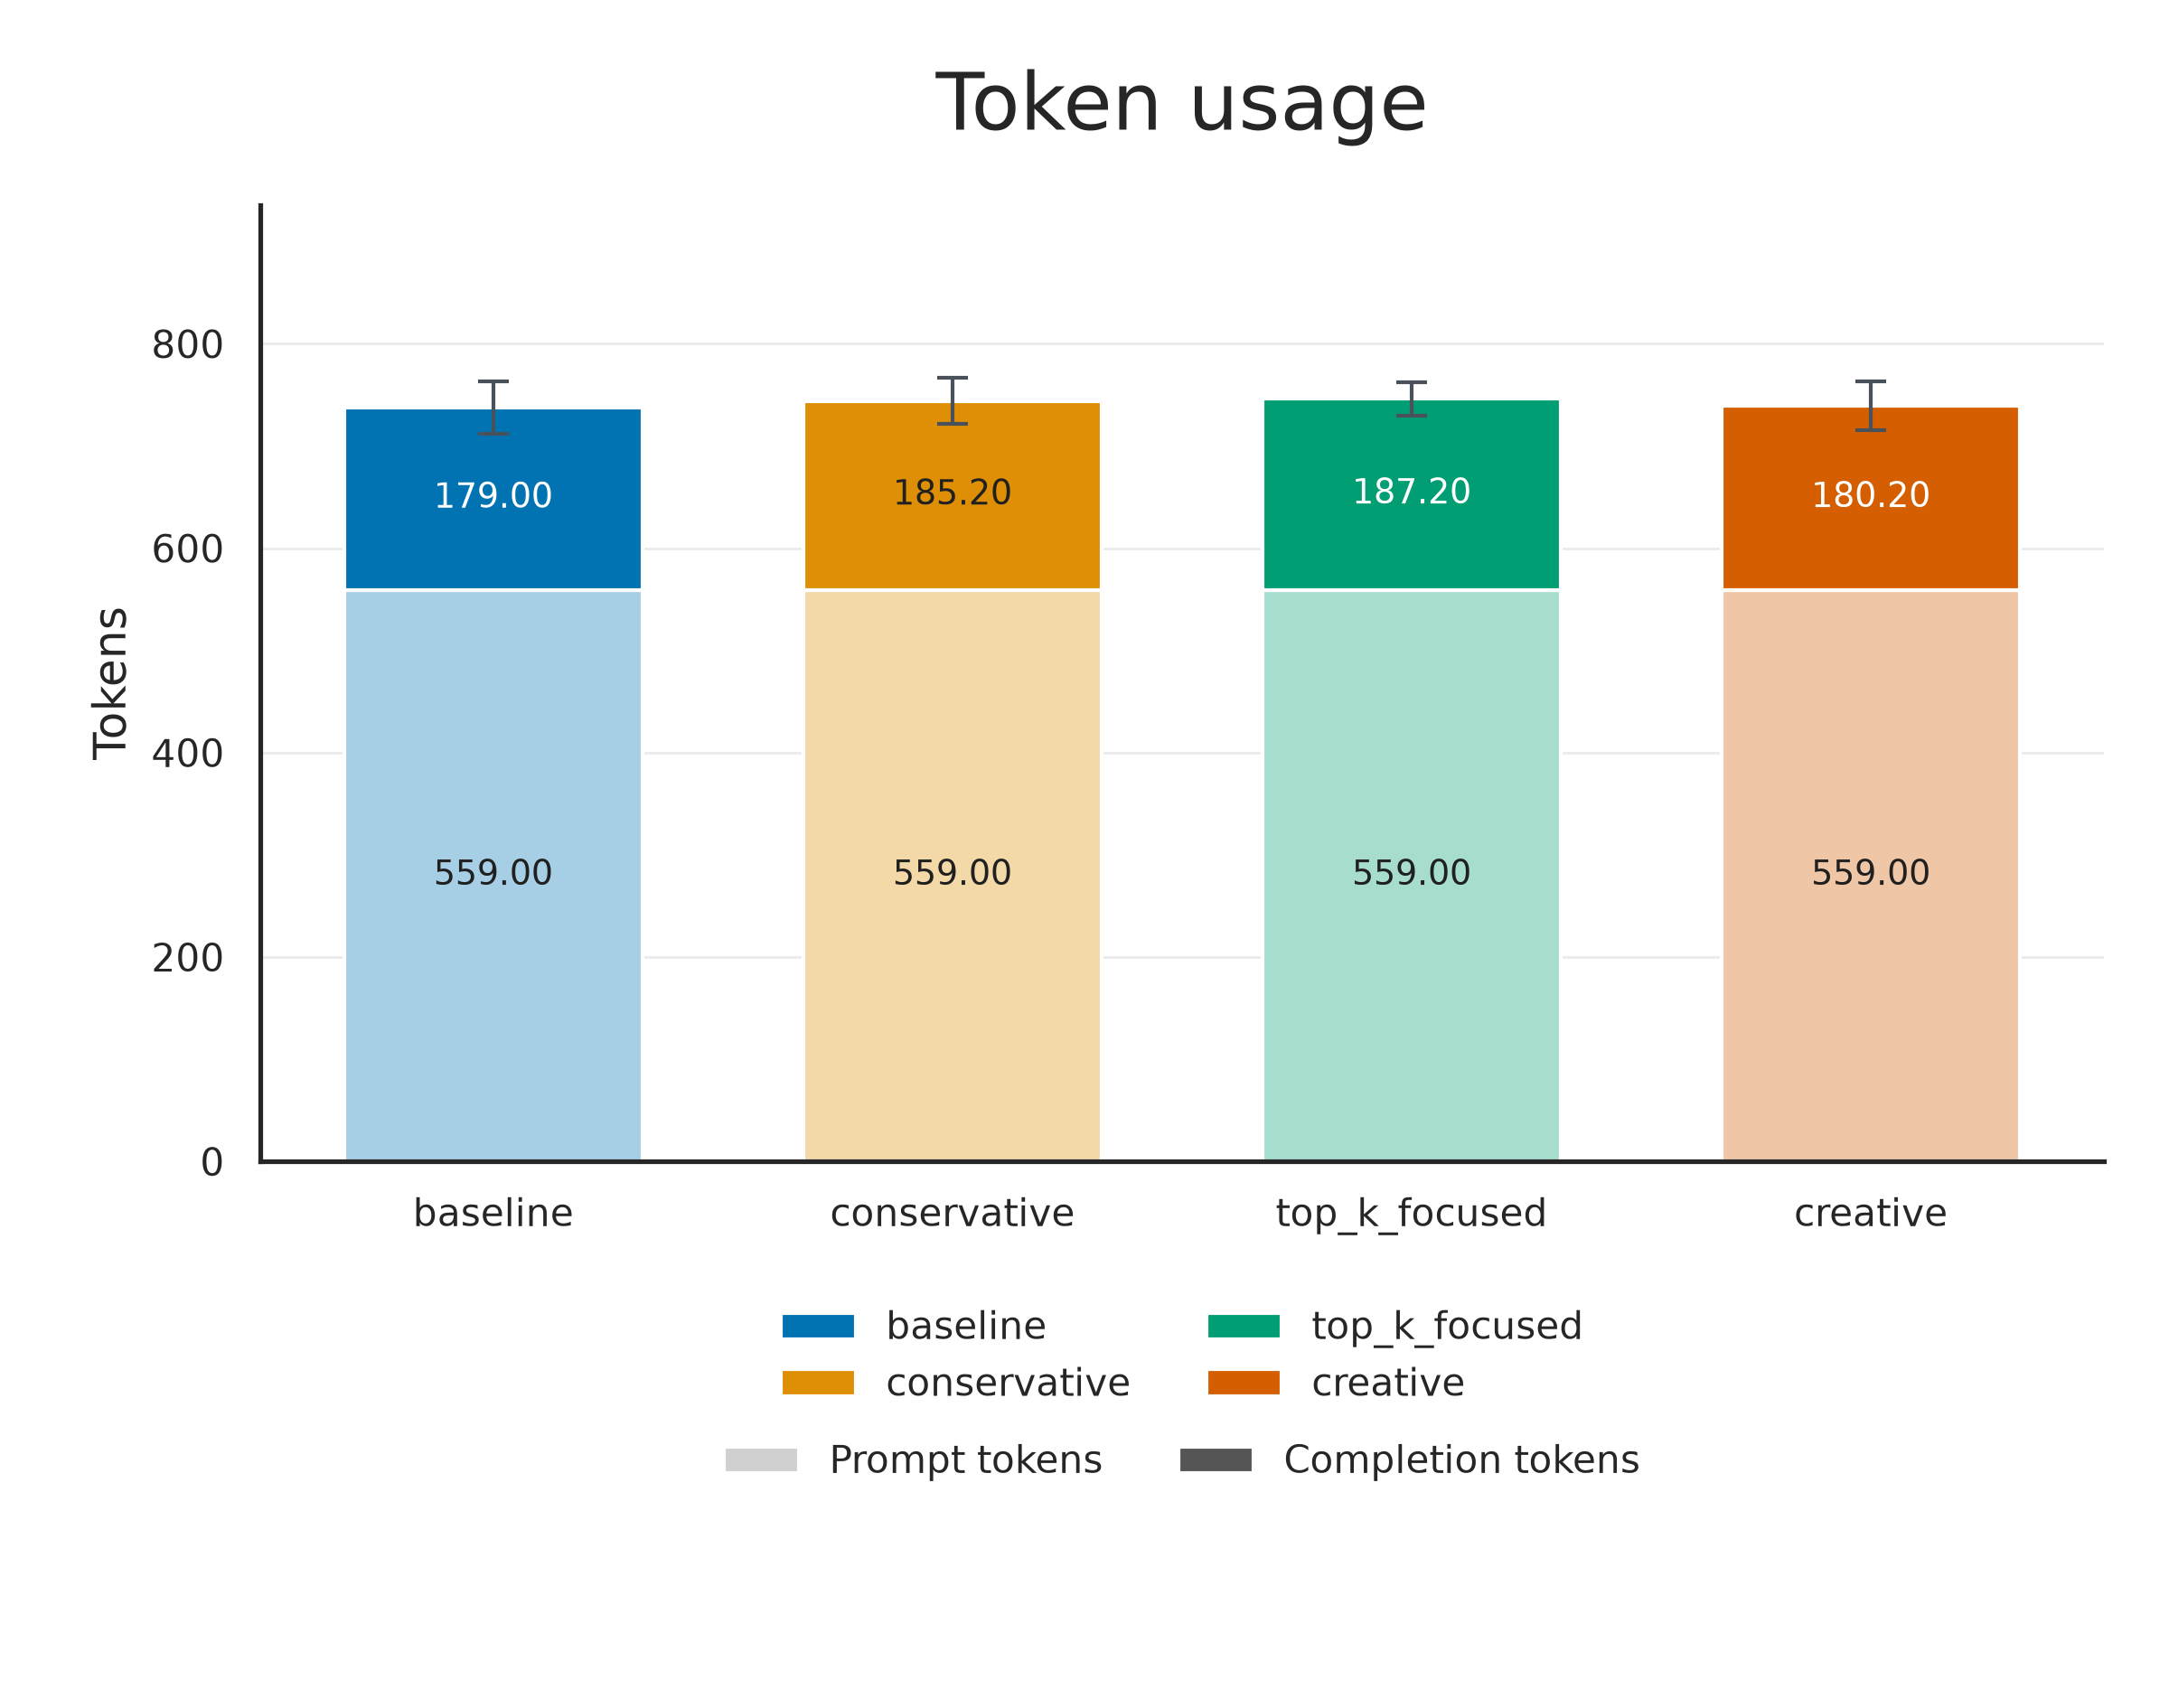

Interactive Plotly figure: usage.html

#### model_comparison · baseline · p1_generation

# Timings

| Model | Cached input tokens (tokens) | Wall time (ms) | TTFT (ms) | Prefill tokens (tokens) | Prefill time (ms) | Prefill time per token (ms/token) | Prefill throughput (tokens/s) | Generated tokens (tokens) | Generation time (ms) | Generation time per token (ms/token) | Generation throughput (tokens/s) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| gemma4 | 0.00 +- 0.00 | **2528.20 +- 231.90** | 249.00 +- 143.76 | 546.00 +- 0.00 | 243.40 +- 143.02 | 0.446 +- 0.262 | 2654.54 +- 876.95 | 241.20 +- 13.66 | **2278.97 +- 151.67** | **9.486 +- 0.290** | **105.49 +- 3.12** |
| phi-4-mini | 0.00 +- 0.00 | 5963.82 +- 570.21 | **176.96 +- 6.72** | 536.00 +- 0.00 | **170.41 +- 7.51** | **0.318 +- 0.014** | **3150.08 +- 135.13** | 462.00 +- 52.91 | 5786.53 +- 568.38 | 12.572 +- 0.258 | 79.57 +- 1.61 |
| qwen3.5-4b | 0.00 +- 0.00 | 2887.95 +- 338.93 | 365.63 +- 64.46 | 559.00 +- 0.00 | 340.03 +- 22.99 | 0.608 +- 0.041 | 1650.06 +- 113.01 | 179.00 +- 25.66 | 2522.08 +- 364.40 | 14.168 +- 0.051 | 70.58 +- 0.25 |


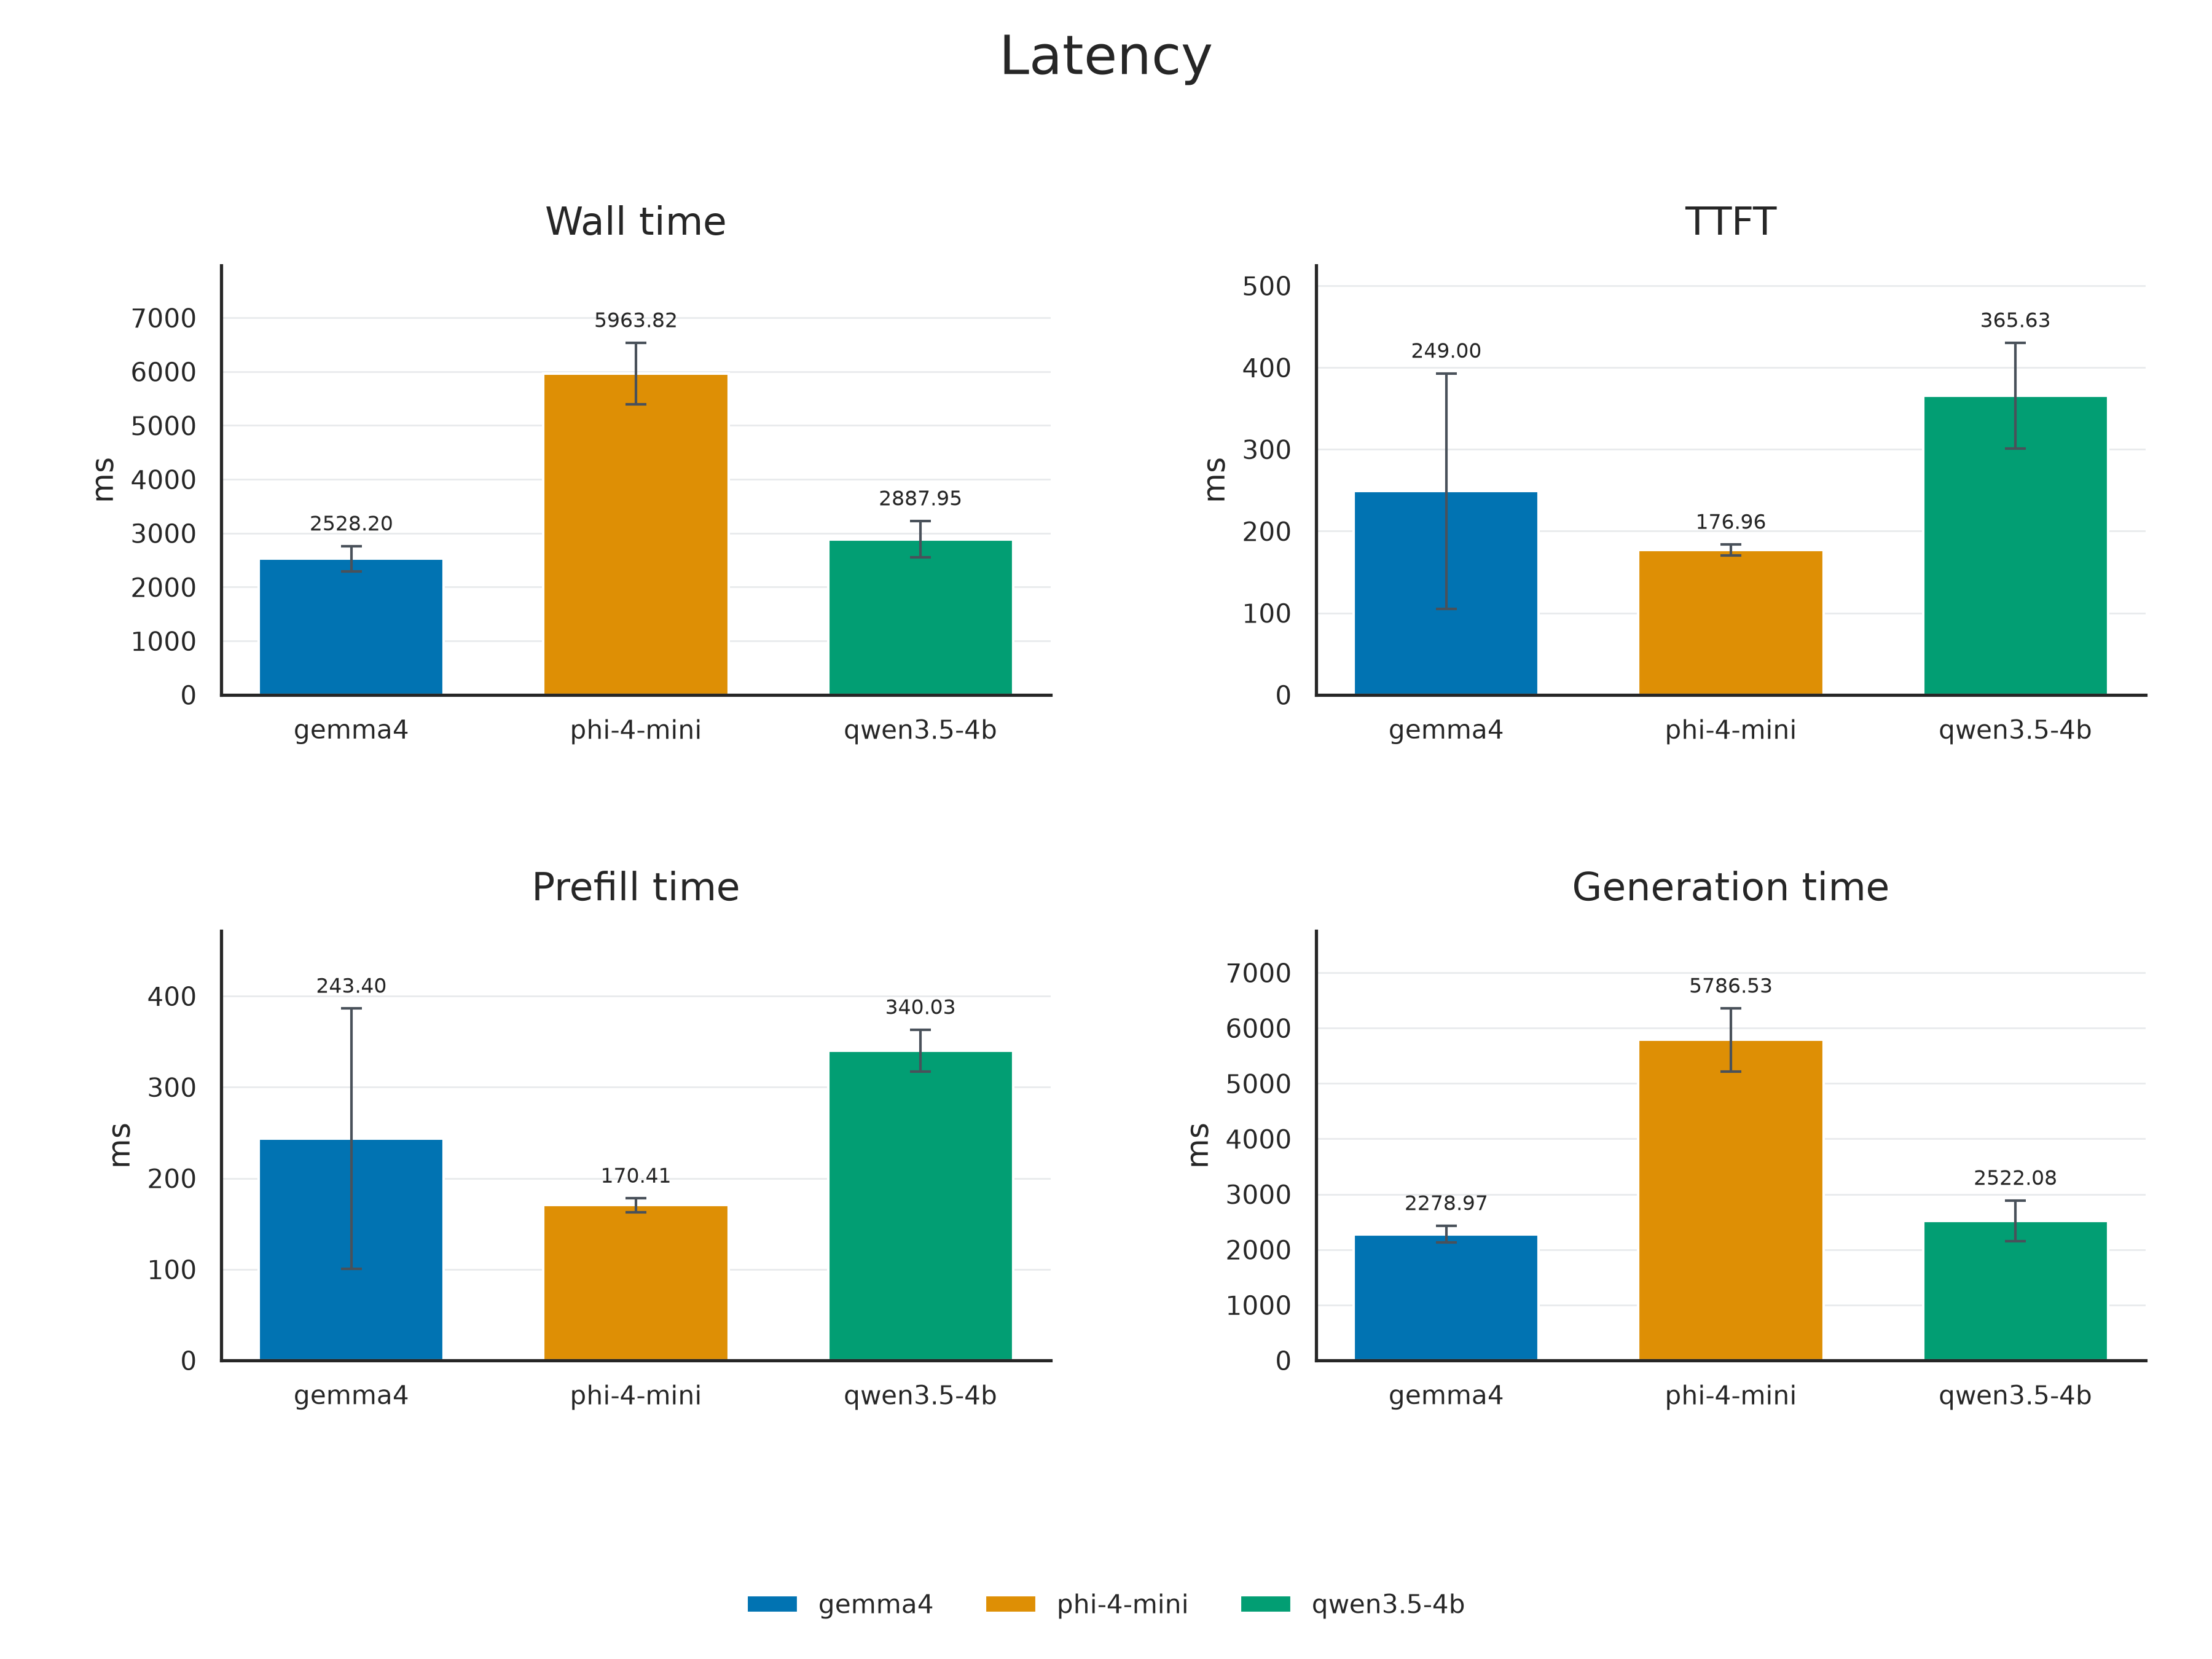

Interactive Plotly figure: latency_baseline.html

#### preset_comparison · gemma4 · p2_classification

# Classification accuracy

| Metric | baseline | conservative | top_k_focused | creative |
| --- | --- | --- | --- | --- |
| Accuracy (%) | **80.00 +- 3.04** | 77.78 +- 0.00 | 77.78 +- 0.00 | **80.00 +- 3.04** |
| Correct classifications (answers) | **14.40 +- 0.55** | 14.00 +- 0.00 | 14.00 +- 0.00 | **14.40 +- 0.55** |


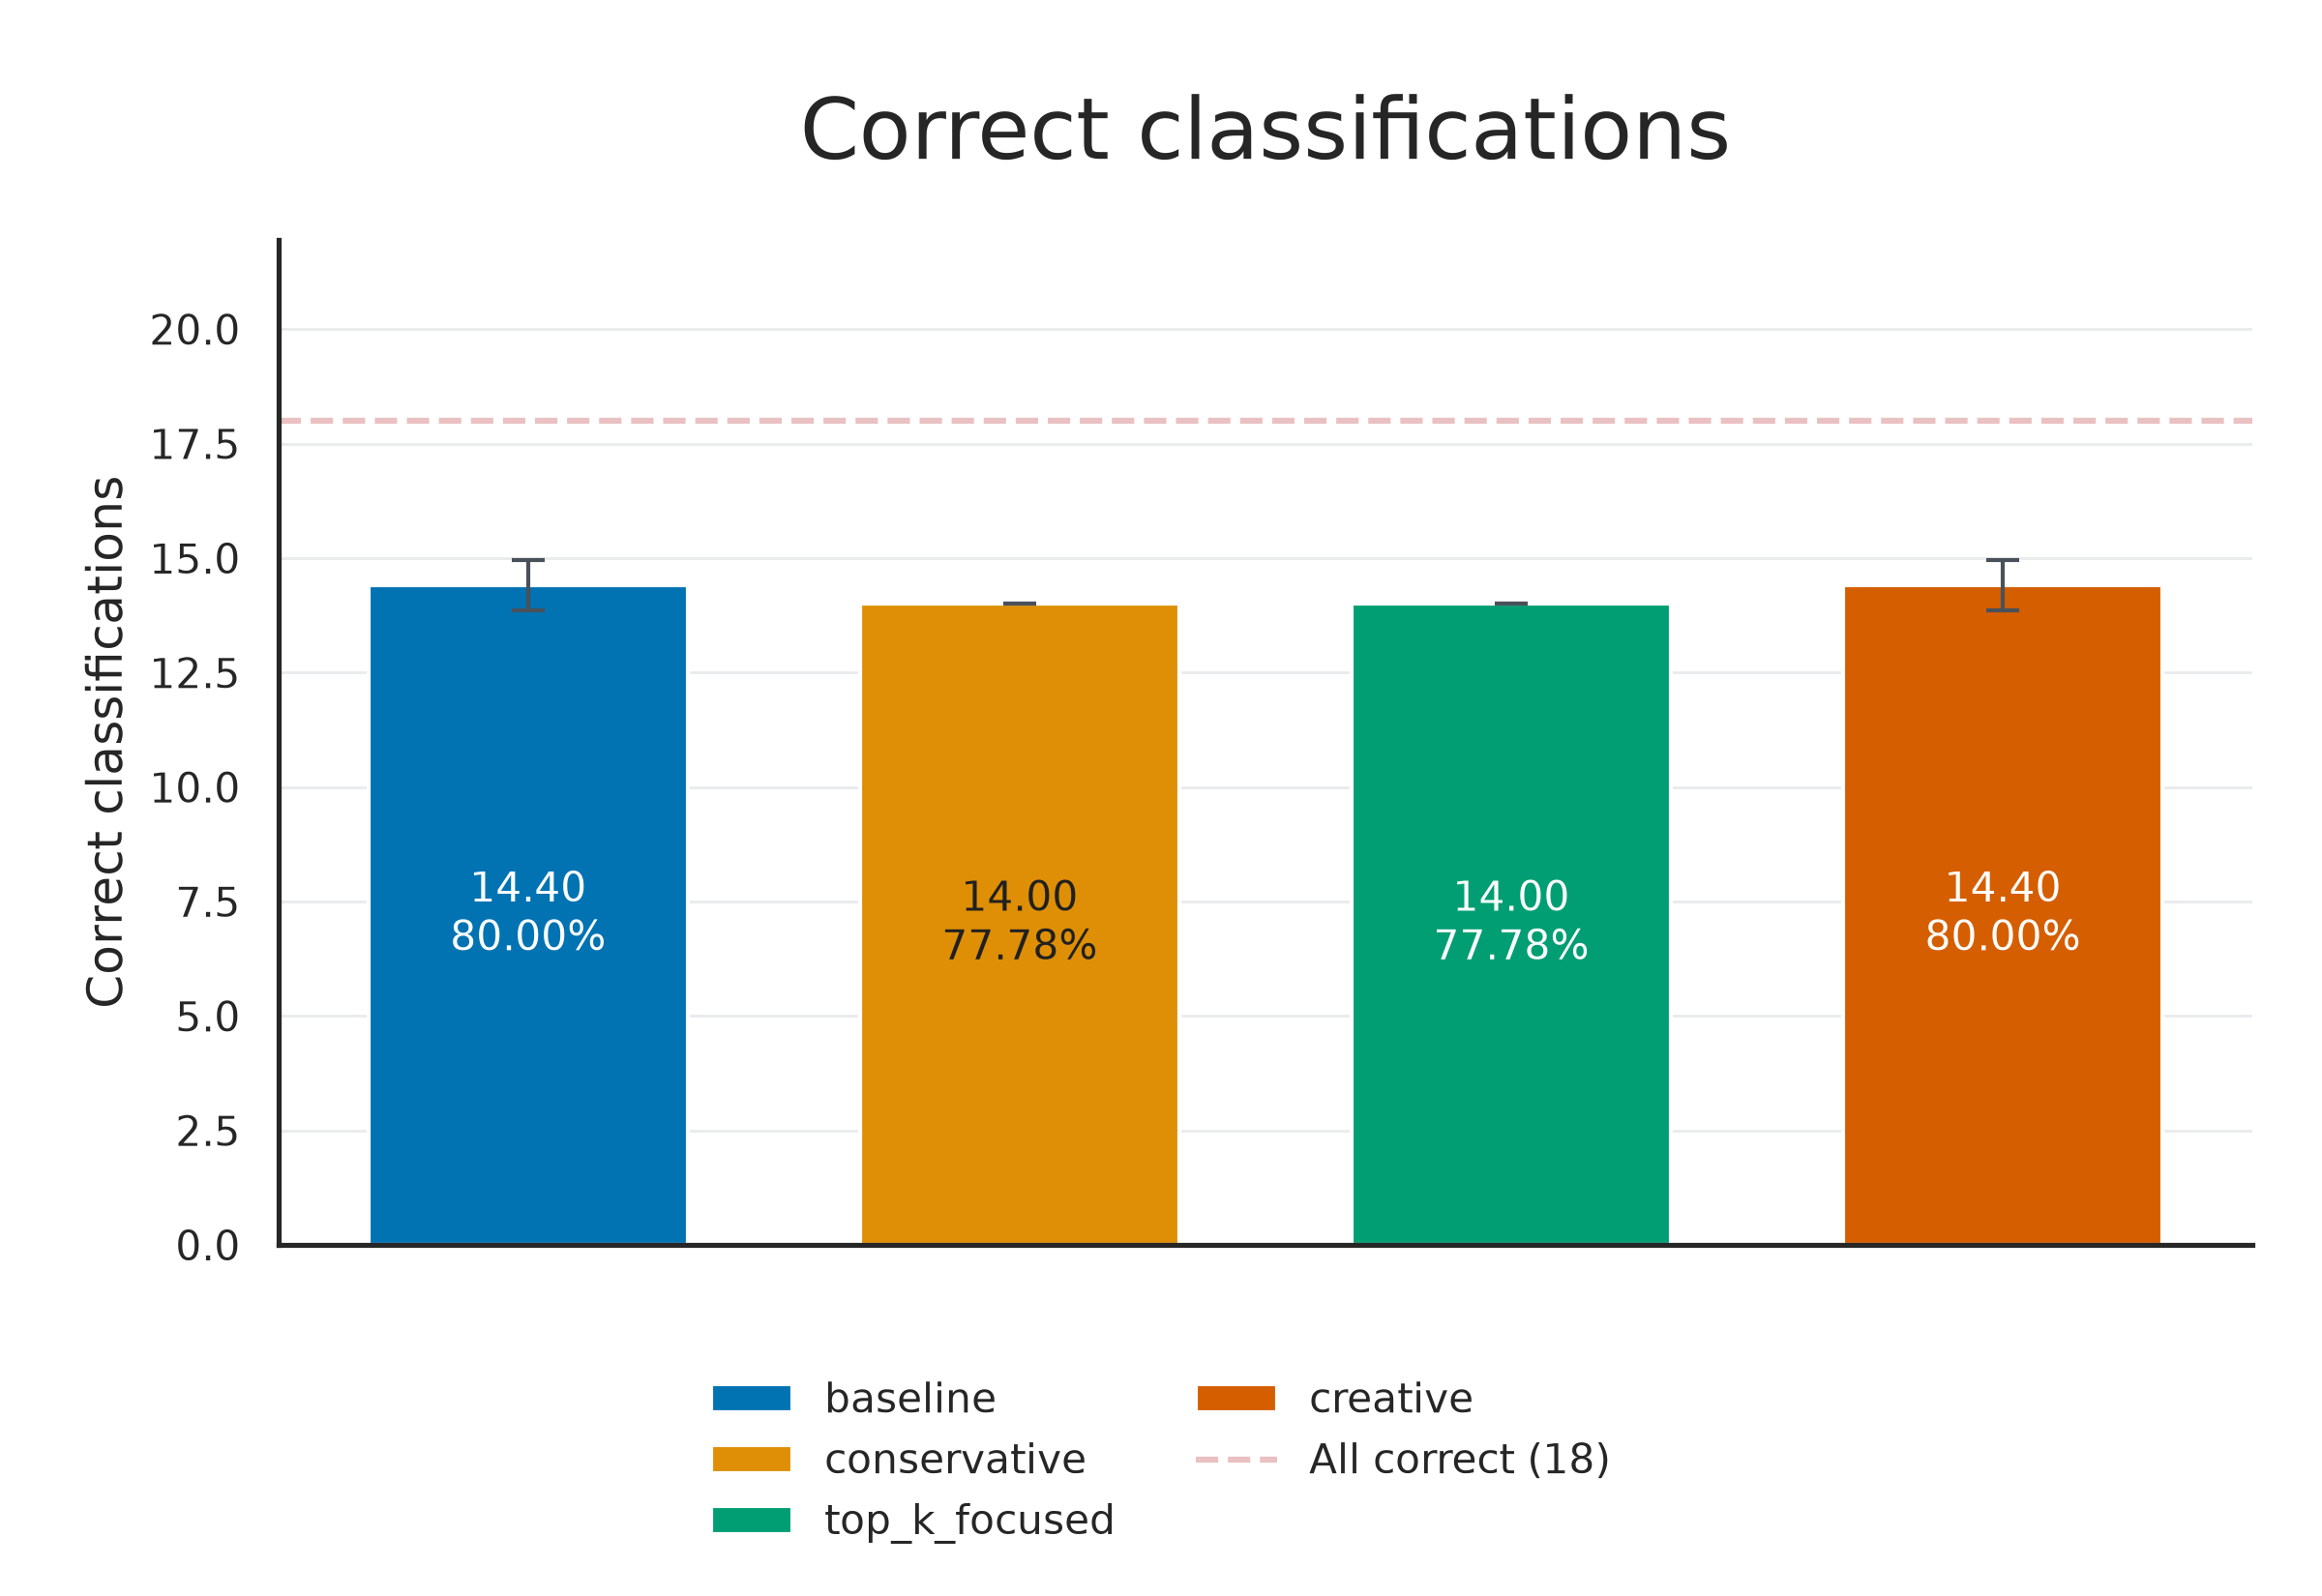

Interactive Plotly figure: classification.html

#### model_comparison · baseline · p2_classification

# Classification accuracy

| Model | Accuracy (%) | Correct classifications (answers) |
| --- | --- | --- |
| gemma4 | 80.00 +- 3.04 | 14.40 +- 0.55 |
| phi-4-mini | **82.22 +- 6.09** | **14.80 +- 1.10** |
| qwen3.5-4b | 80.00 +- 3.04 | 14.40 +- 0.55 |


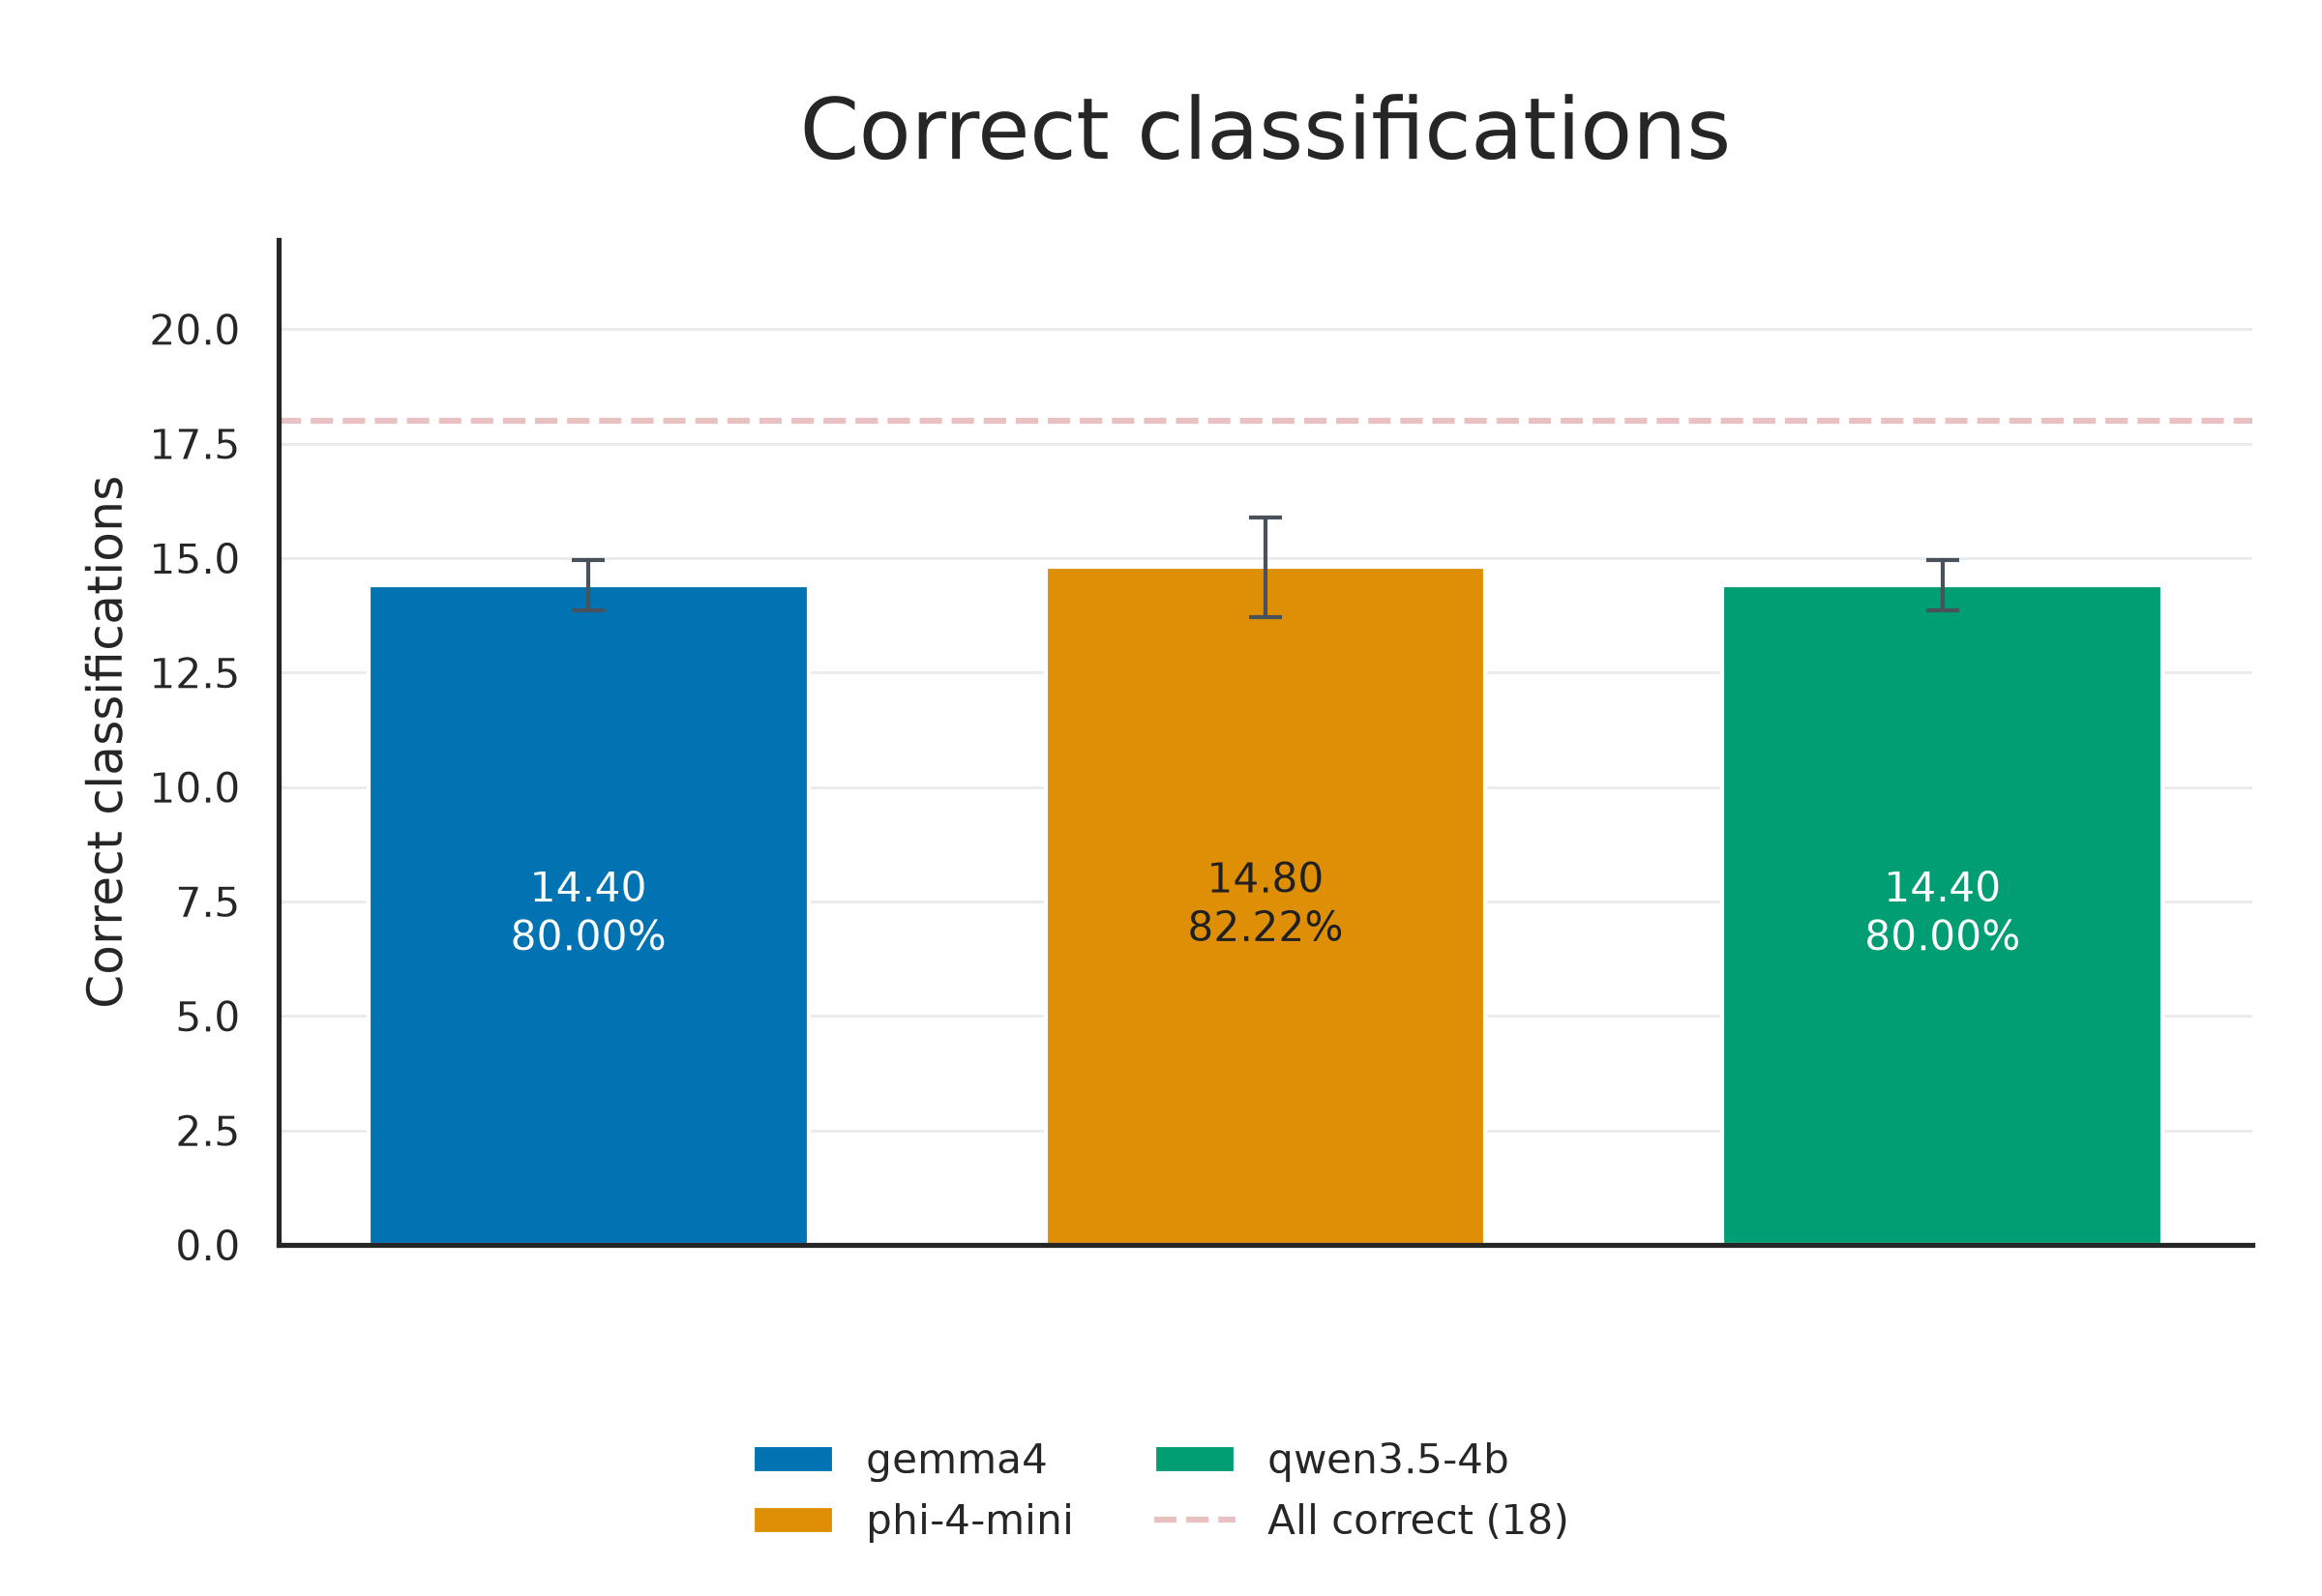

Interactive Plotly figure: classification_baseline.html

#### preset_comparison · phi-4-mini · p3_summary

# Timings

| Metric | baseline | conservative | top_k_focused | creative |
| --- | --- | --- | --- | --- |
| Cached input tokens (tokens) | 0.00 +- 0.00 | 0.00 +- 0.00 | 0.00 +- 0.00 | 0.00 +- 0.00 |
| Wall time (ms) | **4369.26 +- 1295.98** | 4441.33 +- 983.69 | 4448.40 +- 1369.55 | 5326.27 +- 1157.52 |
| TTFT (ms) | **728.09 +- 31.79** | 729.07 +- 49.31 | 808.03 +- 47.30 | 874.52 +- 27.01 |
| Prefill tokens (tokens) | 1176.00 +- 0.00 | 1176.00 +- 0.00 | 1176.00 +- 0.00 | 1176.00 +- 0.00 |
| Prefill time (ms) | **675.59 +- 79.07** | 720.69 +- 49.42 | 799.12 +- 47.29 | 866.02 +- 26.70 |
| Prefill time per token (ms/token) | **0.574 +- 0.067** | 0.613 +- 0.042 | 0.680 +- 0.040 | 0.736 +- 0.023 |
| Prefill throughput (tokens/s) | **1762.85 +- 237.32** | 1638.34 +- 119.70 | 1475.63 +- 84.94 | 1358.98 +- 42.27 |
| Generated tokens (tokens) | 131.60 +- 38.21 | 138.40 +- 34.86 | 129.20 +- 46.74 | 144.40 +- 33.60 |
| Generation time (ms) | 3640.80 +- 1317.78 | 3711.83 +- 943.24 | **3639.88 +- 1357.87** | 4451.38 +- 1144.16 |
| Generation time per token (ms/token) | 27.424 +- 3.036 | **27.028 +- 0.673** | 28.304 +- 1.411 | 30.889 +- 1.137 |
| Generation throughput (tokens/s) | 36.83 +- 4.11 | **37.02 +- 0.92** | 35.40 +- 1.75 | 32.41 +- 1.25 |


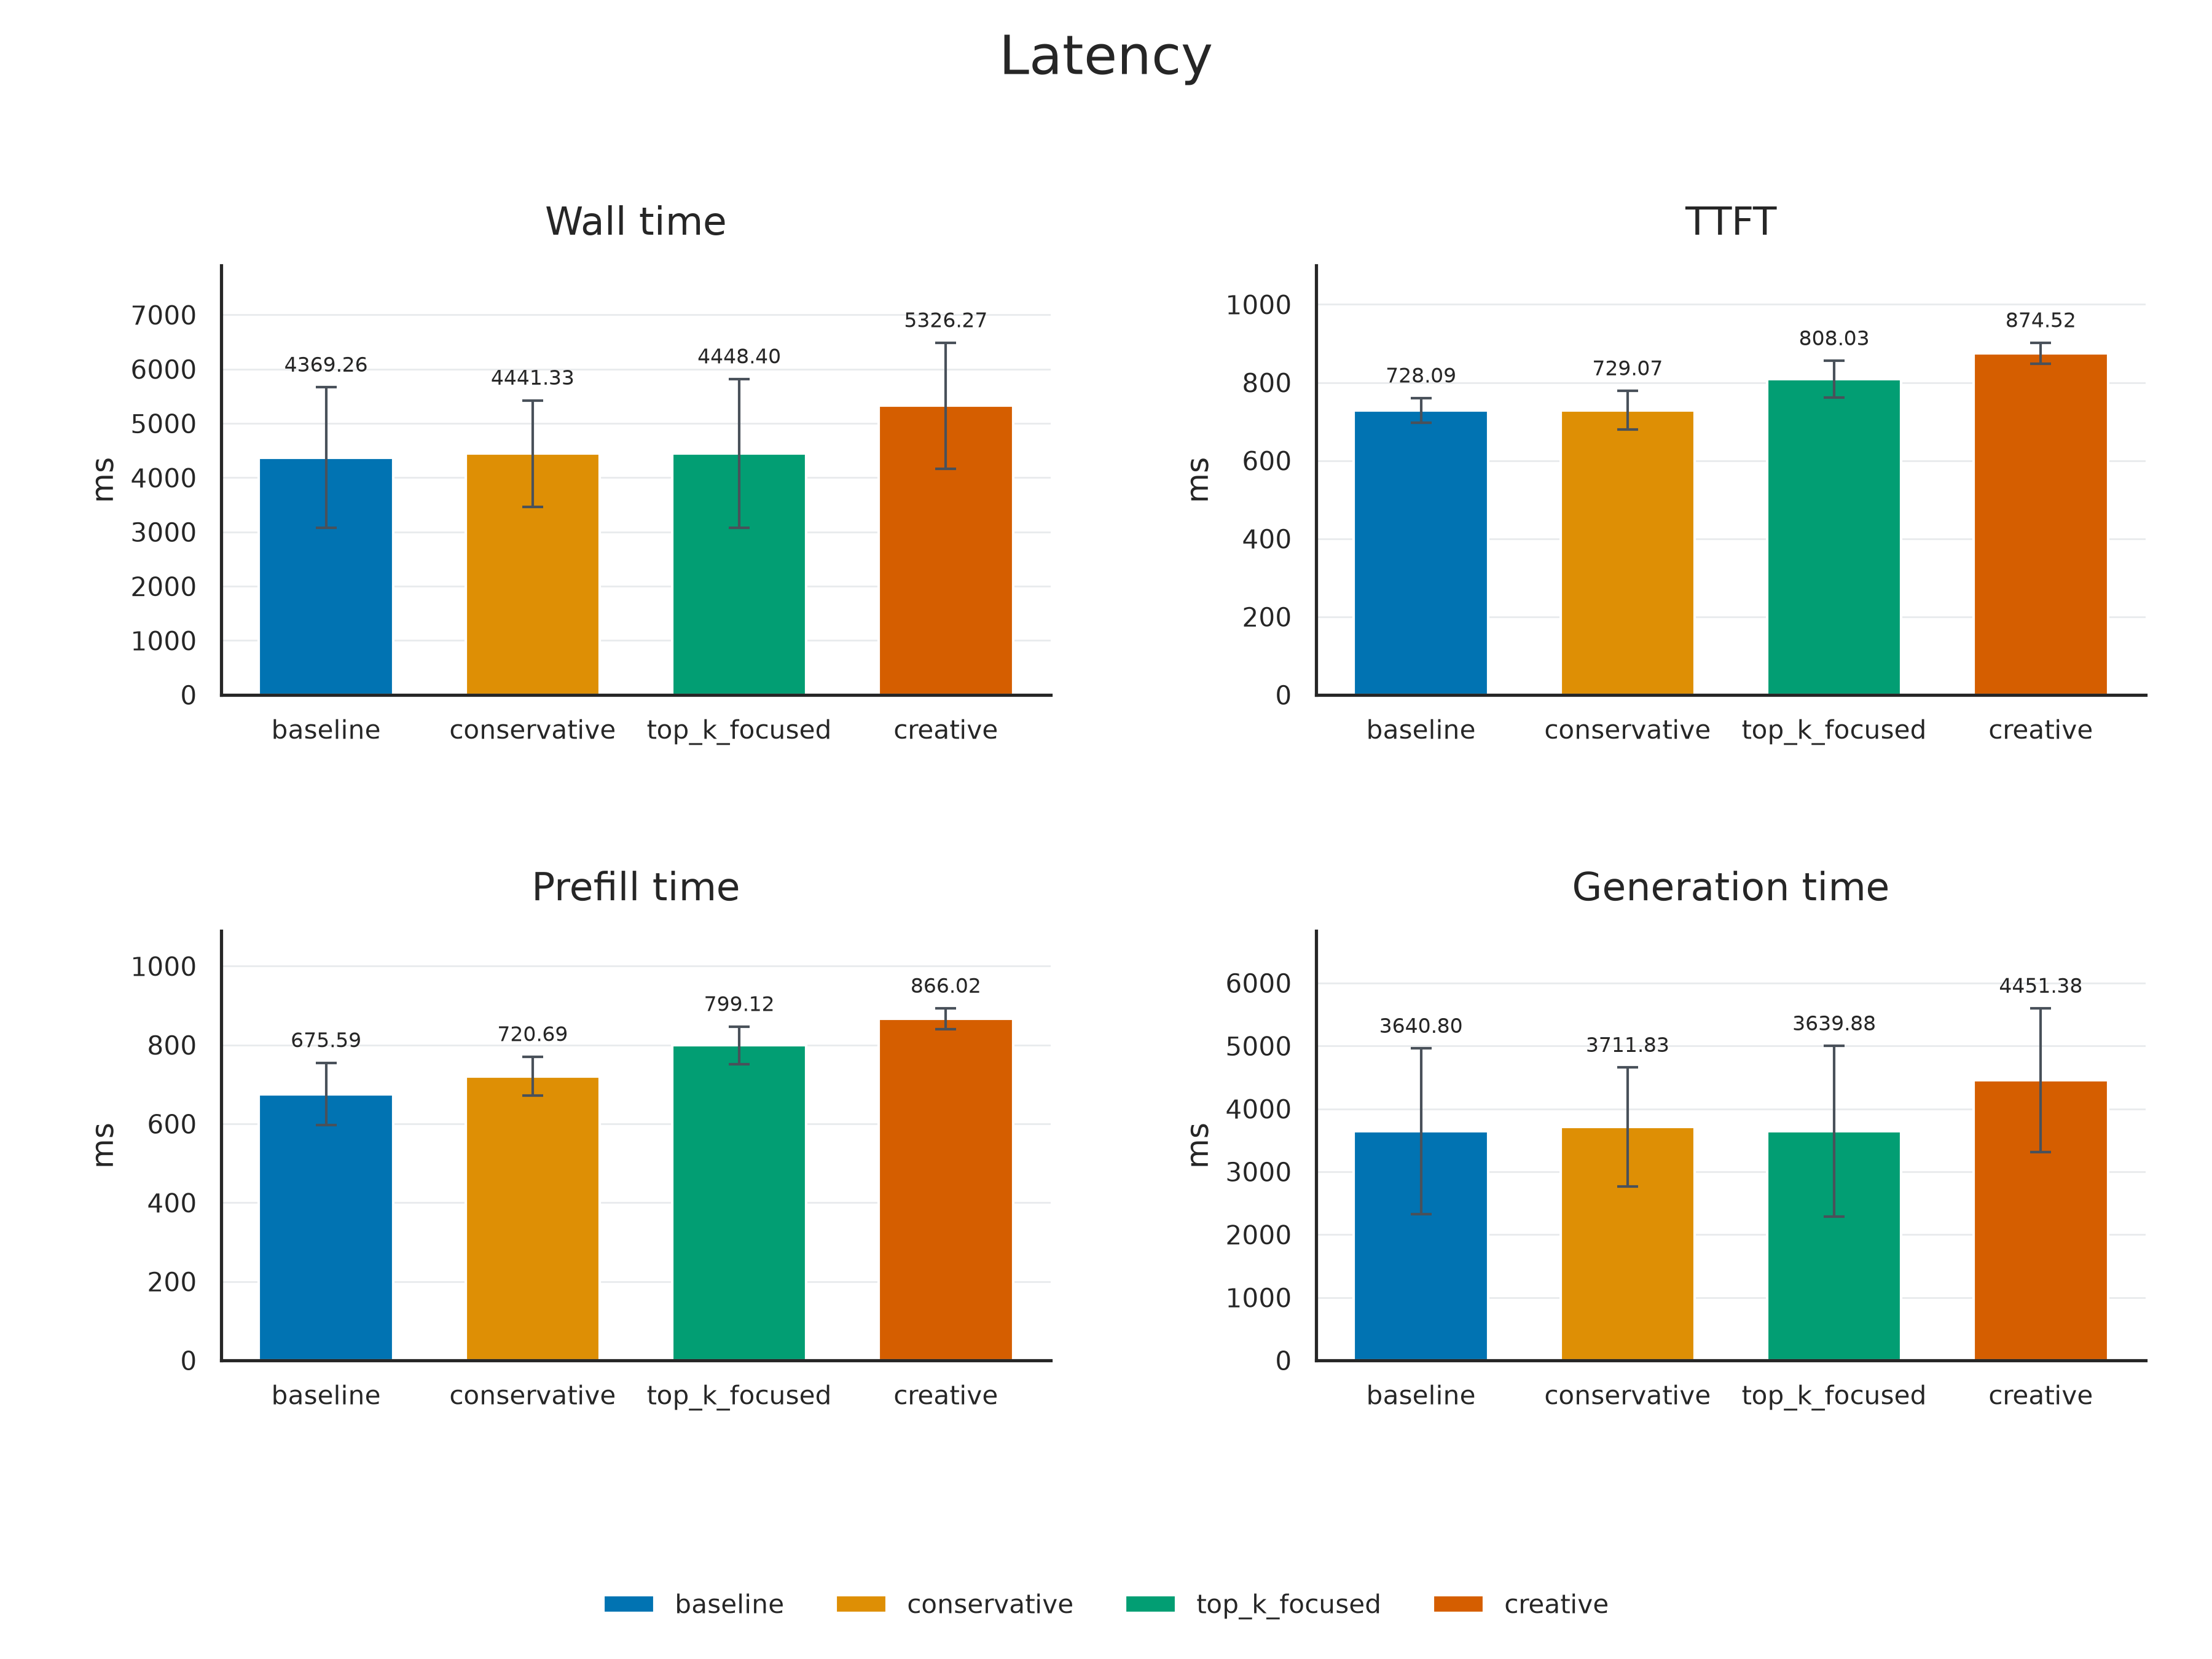

Interactive Plotly figure: latency.html

#### model_comparison · baseline · p3_summary

# Token usage

| Model | Completion tokens (tokens) | Prompt tokens (tokens) | Total tokens (tokens) | Cached tokens (tokens) |
| --- | --- | --- | --- | --- |
| gemma4 | 156.60 +- 9.02 | 1184.00 +- 0.00 | 1340.60 +- 9.02 | 0.00 +- 0.00 |
| phi-4-mini | 131.60 +- 38.21 | 1176.00 +- 0.00 | 1307.60 +- 38.21 | 0.00 +- 0.00 |
| qwen3.5-4b | 179.80 +- 21.43 | 1203.00 +- 0.00 | 1382.80 +- 21.43 | 0.00 +- 0.00 |


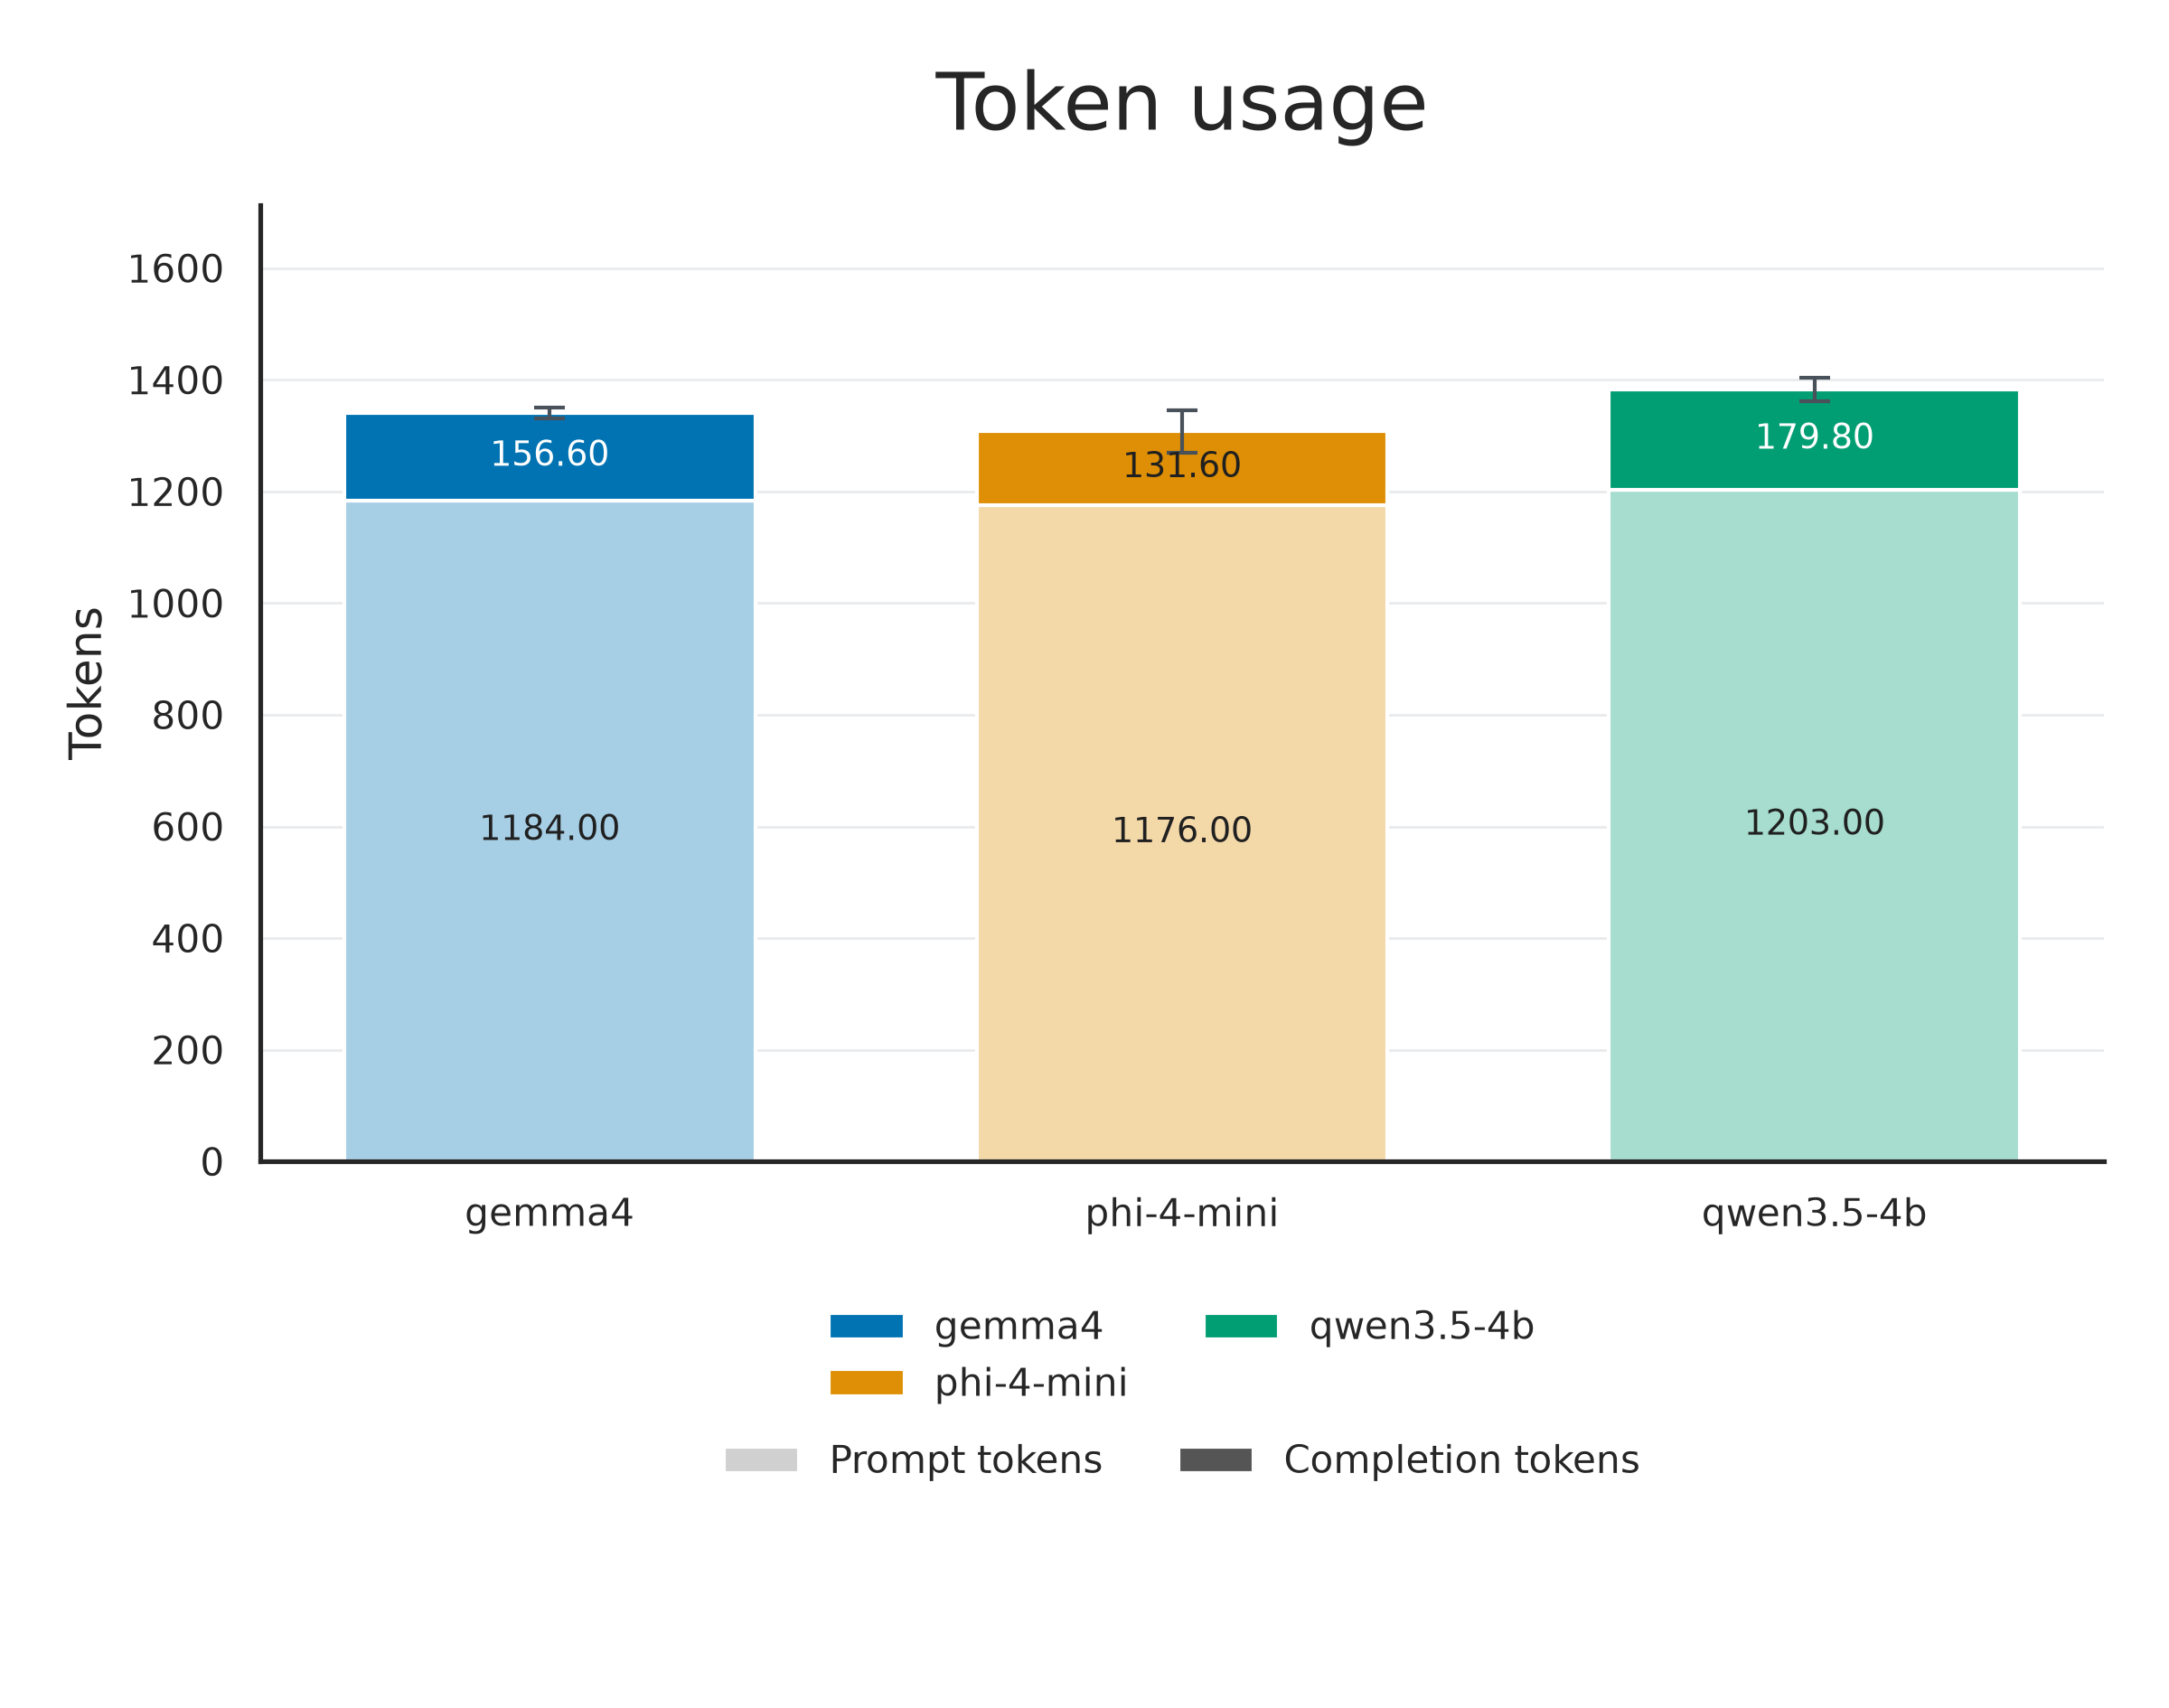

Interactive Plotly figure: usage_baseline.html

#### P2 · Error frequency

# Classification error frequency

| Review | Expected class | Incorrect predictions | Total predictions |
| --- | --- | --- | --- |
| 1 | Good | 0 | 5 |
| 2 | Good | 0 | 5 |
| 3 | Bad | 0 | 5 |
| 4 | Good | 0 | 5 |
| 5 | Bad | 0 | 5 |
| 6 | Bad | 0 | 5 |
| 7 | Neutral | 0 | 5 |
| 8 | Bad | 5 | 5 |
| 9 | Neutral | 0 | 5 |
| 10 | Neutral | 3 | 5 |
| 11 | Good | 0 | 5 |
| 12 | Neutral | 5 | 5 |
| 13 | Good | 0 | 5 |
| 14 | Good | 0 | 5 |
| 15 | Neutral | 0 | 5 |
| 16 | Bad | 0 | 5 |
| 17 | Bad | 0 | 5 |
| 18 | Neutral | 5 | 5 |


In [36]:
PREVIEW_SELECTION = [
    ("preset_comparison", "qwen3.5-4b", "p1_generation", "usage"),
    ("model_comparison", "baseline", "p1_generation", "latency"),
    ("preset_comparison", "gemma4", "p2_classification", "classification"),
    ("model_comparison", "baseline", "p2_classification", "classification"),
    ("preset_comparison", "phi-4-mini", "p3_summary", "latency"),
    ("model_comparison", "baseline", "p3_summary", "usage"),
]
for kind, identity, task, panel in PREVIEW_SELECTION:
    display(Markdown(f"#### {kind} · {identity} · {task}"))
    category = panel if panel in ("usage", "classification") else "timings"
    display(Markdown(table_previews[(kind, identity, task, category)]))
    path, figure, html_path = figure_previews[(kind, identity, task, panel)]
    display(DisplayImage(filename=str(path), width=1000))
    display({
        "application/vnd.plotly.v1+json": json.loads(figure.to_json()),
        "text/plain": f"Interactive Plotly figure: {html_path.name}",
    }, raw=True)

display(Markdown("#### P2 · Error frequency"))
display(Markdown(error_table_previews[("gemma4", "baseline")]))
print(f"Report materials: {REPORT_DIR}")
print(f"Comparisons: {len(MODELS) * len(TASKS)} preset comparisons, "
      f"{len(TASKS) * len(PRESETS)} model comparisons.")
